<a href="https://colab.research.google.com/github/marceleazoliveira/TF_IA/blob/main/TF_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [250]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Ellipse, Polygon

In [251]:
# Configurações gerais

# São 5 classes de forma, com 5 objetos de cada classe
N_POR_CLASSE = 5

cores = ["red", "green", "blue"]

# Formas adaptadas para o cenário 2D
# cylinder -> ellipse
# cone -> rectangle
formas = ["circle", "square", "ellipse", "rectangle", "triangle"]

# Total de objetos: 5 classes * 5 objetos por classe = 25
N_OBJETOS = len(formas) * N_POR_CLASSE

# Tamanhos: 1x1, 2x2, 3x3
tamanhos = [1, 2, 3]

# Tamanho visual usado no gráfico
BASE_VISUAL = 0.018

In [252]:
def criar_vetor(objeto):
    """
    Cria o vetor de características do objeto.

    Estrutura:
    [0, 1]            -> x, y
    [2, 3, 4]         -> cor one-hot: red, green, blue
    [5, 6, 7, 8, 9]   -> forma one-hot: circle, square, ellipse, rectangle, triangle
    [10]              -> tamanho normalizado
    """

    x = objeto["x"]
    y = objeto["y"]

    # One-hot da cor
    cor_one_hot = [0, 0, 0]
    indice_cor = cores.index(objeto["cor"])
    cor_one_hot[indice_cor] = 1

    # One-hot da forma
    forma_one_hot = [0, 0, 0, 0, 0]
    indice_forma = formas.index(objeto["forma"])
    forma_one_hot[indice_forma] = 1

    # Tamanho normalizado
    # 1x1 -> 1/3
    # 2x2 -> 2/3
    # 3x3 -> 1
    tamanho_normalizado = objeto["tamanho"] / 3

    vetor = [x, y] + cor_one_hot + forma_one_hot + [tamanho_normalizado]

    return vetor


def dimensoes_objeto(forma, tamanho):
    escala = BASE_VISUAL * tamanho

    if forma == "circle":
        largura = 2 * escala
        altura = 2 * escala

    elif forma == "square":
        largura = 2 * escala
        altura = 2 * escala

    elif forma == "rectangle":
        largura = 2.8 * escala
        altura = 1.4 * escala

    elif forma == "ellipse":
        largura = 3.0 * escala
        altura = 1.5 * escala

    elif forma == "triangle":
        largura = 2.4 * escala
        altura = 2.3 * escala

    return largura, altura


def tem_sobreposicao(x, y, forma, tamanho, objetos, margem=0.015):
    largura, altura = dimensoes_objeto(forma, tamanho)

    for obj in objetos:
        largura2, altura2 = dimensoes_objeto(obj["forma"], obj["tamanho"])

        distancia_x = abs(x - obj["x"])
        distancia_y = abs(y - obj["y"])

        limite_x = (largura / 2) + (largura2 / 2) + margem
        limite_y = (altura / 2) + (altura2 / 2) + margem

        if distancia_x < limite_x and distancia_y < limite_y:
            return True

    return False


def gerar_objetos(n_por_classe=5):
    """
    Gera uma cena com 5 classes de objetos e n_por_classe objetos por classe.

    Exemplo:
    5 círculos
    5 quadrados
    5 elipses
    5 retângulos
    5 triângulos

    Total: 25 objetos.
    """

    objetos = []

    # Garante exatamente 5 objetos de cada classe
    formas_da_cena = []

    for forma in formas:
        for _ in range(n_por_classe):
            formas_da_cena.append(forma)

    # Embaralha para a ordem dos objetos na cena ficar aleatória
    np.random.shuffle(formas_da_cena)

    tentativas = 0
    max_tentativas = 30000

    indice_forma = 0

    while len(objetos) < len(formas_da_cena) and tentativas < max_tentativas:
        tentativas += 1

        forma = formas_da_cena[indice_forma]
        cor = np.random.choice(cores)
        tamanho = int(np.random.choice(tamanhos))

        largura, altura = dimensoes_objeto(forma, tamanho)

        # Evita gerar objetos cortados nas bordas
        x = float(np.random.uniform(largura / 2, 1 - largura / 2))
        y = float(np.random.uniform(altura / 2, 1 - altura / 2))

        # Evita overlapping
        if tem_sobreposicao(x, y, forma, tamanho, objetos):
            continue

        objeto = {
            "id": len(objetos),
            "x": x,
            "y": y,
            "cor": cor,
            "forma": forma,
            "tamanho": tamanho,
            "tamanho_nome": f"{tamanho}x{tamanho}"
        }

        objeto["vetor"] = criar_vetor(objeto)

        objetos.append(objeto)

        # Só passa para a próxima forma quando o objeto atual foi aceito
        indice_forma += 1

    if len(objetos) < len(formas_da_cena):
        print(f"Aviso: só consegui gerar {len(objetos)} objetos sem sobreposição.")

    return objetos

In [253]:
# Cena de treino: uma única "imagem" com 25 objetos
objetos = gerar_objetos(n_por_classe=N_POR_CLASSE)

df = pd.DataFrame(objetos)

df[["id", "x", "y", "cor", "forma", "tamanho_nome", "vetor"]]

,id,x,y,cor,forma,tamanho_nome,vetor
0,0,0.190648,0.876978,blue,ellipse,1x1,"[0.19064784721737577, 0.8769783759006317, 0, 0..."
1,1,0.800317,0.497221,green,square,2x2,"[0.8003169759036055, 0.4972205516600074, 0, 1,..."
2,2,0.865062,0.839267,red,square,2x2,"[0.8650619055207791, 0.8392674985171041, 1, 0,..."
3,3,0.725384,0.257128,blue,triangle,1x1,"[0.7253840912481783, 0.2571277456298189, 0, 0,..."
4,4,0.483054,0.814398,blue,circle,2x2,"[0.48305428651167087, 0.8143980792555989, 0, 0..."
5,5,0.586716,0.311066,blue,rectangle,2x2,"[0.5867161027904759, 0.3110662546715193, 0, 0,..."
6,6,0.193279,0.151890,green,circle,2x2,"[0.19327912078051024, 0.1518899437707542, 0, 1..."
7,7,0.323275,0.416309,blue,triangle,1x1,"[0.32327456220571343, 0.41630901829619, 0, 0, ..."
8,8,0.192807,0.593280,red,triangle,2x2,"[0.19280671706334768, 0.5932795887853944, 1, 0..."
9,9,0.264625,0.860213,green,ellipse,1x1,"[0.2646249252989, 0.8602129514847404, 0, 1, 0,..."


In [254]:
def plotar_cenario(objetos, titulo="Cenário CLEVR simplificado", salvar_em=None):
    plt.figure(figsize=(8, 6))
    ax = plt.gca()

    for obj in objetos:
        x = obj["x"]
        y = obj["y"]
        cor = obj["cor"]
        forma = obj["forma"]
        tamanho = obj["tamanho"]

        escala = BASE_VISUAL * tamanho

        if forma == "circle":
            patch = Circle(
                (x, y),
                radius=escala,
                facecolor=cor,
                edgecolor="black"
            )

        elif forma == "square":
            patch = Rectangle(
                (x - escala, y - escala),
                2 * escala,
                2 * escala,
                facecolor=cor,
                edgecolor="black"
            )

        elif forma == "rectangle":
            patch = Rectangle(
                (x - 1.4 * escala, y - 0.7 * escala),
                2.8 * escala,
                1.4 * escala,
                facecolor=cor,
                edgecolor="black"
            )

        elif forma == "ellipse":
            patch = Ellipse(
                (x, y),
                width=3.0 * escala,
                height=1.5 * escala,
                facecolor=cor,
                edgecolor="black"
            )

        elif forma == "triangle":
            vertices = [
                (x, y + 1.3 * escala),
                (x - 1.2 * escala, y - escala),
                (x + 1.2 * escala, y - escala)
            ]

            patch = Polygon(
                vertices,
                closed=True,
                facecolor=cor,
                edgecolor="black"
            )

        ax.add_patch(patch)
        ax.text(x + 0.01, y + 0.01, str(obj["id"]), fontsize=9)

    plt.title(titulo)
    plt.xlabel("posição x")
    plt.ylabel("posição y")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.gca().set_aspect("equal", adjustable="box")

    if salvar_em is not None:
        plt.savefig(salvar_em, dpi=300, bbox_inches="tight")

    plt.show()

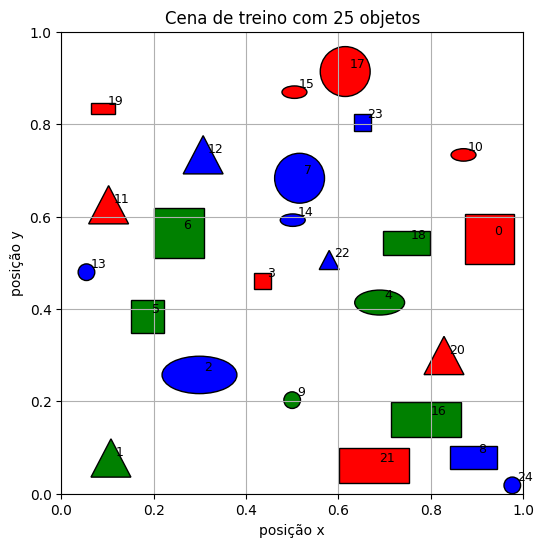

In [255]:
plotar_cenario(
    cena_treino,
    titulo="Cena de treino com 25 objetos",
    salvar_em="figures/cena_treino.png"
)

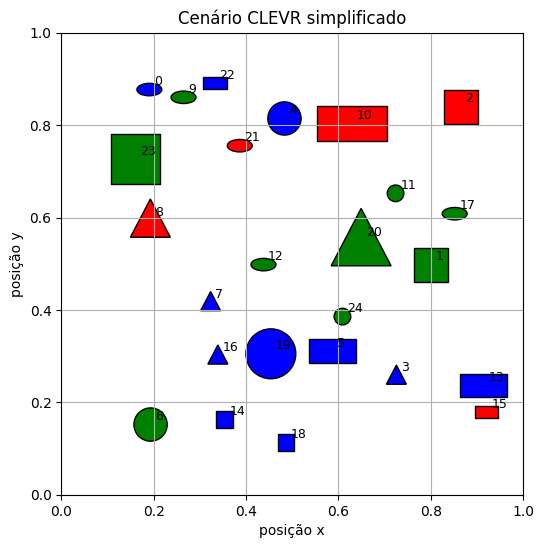

In [256]:
plotar_cenario(objetos)

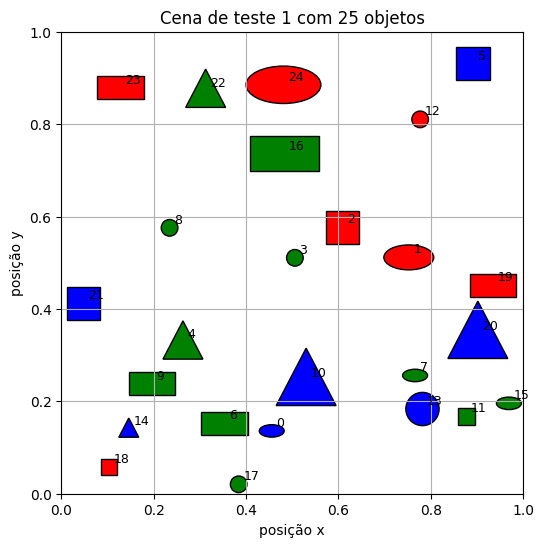

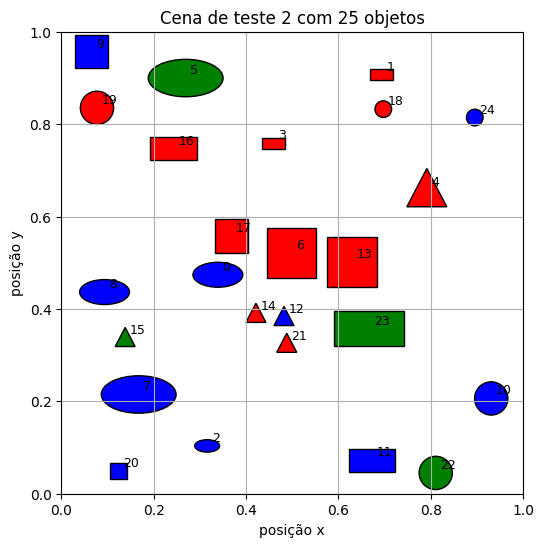

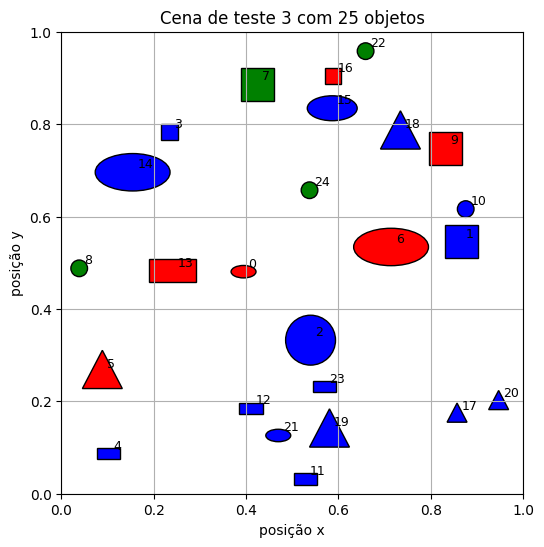

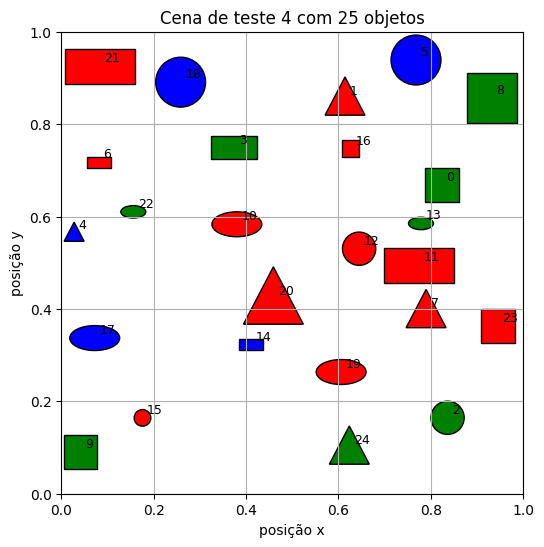

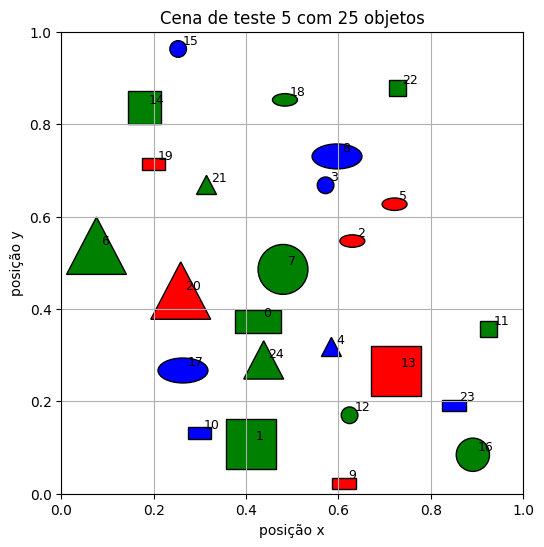

In [257]:
for dataset in datasets_teste:
    id_cena = dataset["id_cena"]
    cena = dataset["objetos"]

    plotar_cenario(
        cena,
        titulo=f"Cena de teste {id_cena} com 25 objetos",
        salvar_em=f"figures/cena_teste_{id_cena}.png"
    )

In [258]:
def left_of(a, b):
    return a["x"] < b["x"]


def right_of(a, b):
    return a["x"] > b["x"]


def below(a, b):
    return a["y"] < b["y"]


def above(a, b):
    return a["y"] > b["y"]


def close_to(a, b, threshold=0.20):
    distancia = np.sqrt((a["x"] - b["x"])**2 + (a["y"] - b["y"])**2)
    return distancia < threshold


def same_size(a, b):
    return a["tamanho"] == b["tamanho"]


def in_between_horizontal(x, y, z):
    return min(y["x"], z["x"]) < x["x"] < max(y["x"], z["x"])


def in_between_vertical(x, y, z):
    return min(y["y"], z["y"]) < x["y"] < max(y["y"], z["y"])


def in_between(x, y, z):
    return in_between_horizontal(x, y, z) or in_between_vertical(x, y, z)

In [259]:
a = objetos[0]
b = objetos[1]

print("Objeto 0:", a)
print("Objeto 1:", b)

print("\nRelações:")
print("0 está à esquerda de 1?", left_of(a, b))
print("0 está à direita de 1?", right_of(a, b))
print("0 está abaixo de 1?", below(a, b))
print("0 está acima de 1?", above(a, b))
print("0 está próximo de 1?", close_to(a, b))
print("0 tem mesmo tamanho que 1?", same_size(a, b))

Objeto 0: {'id': 0, 'x': 0.19064784721737577, 'y': 0.8769783759006317, 'cor': np.str_('blue'), 'forma': 'ellipse', 'tamanho': 1, 'tamanho_nome': '1x1', 'vetor': [0.19064784721737577, 0.8769783759006317, 0, 0, 1, 0, 0, 1, 0, 0, 0.3333333333333333]}
Objeto 1: {'id': 1, 'x': 0.8003169759036055, 'y': 0.4972205516600074, 'cor': np.str_('green'), 'forma': 'square', 'tamanho': 2, 'tamanho_nome': '2x2', 'vetor': [0.8003169759036055, 0.4972205516600074, 0, 1, 0, 0, 1, 0, 0, 0, 0.6666666666666666]}

Relações:
0 está à esquerda de 1? True
0 está à direita de 1? False
0 está abaixo de 1? False
0 está acima de 1? True
0 está próximo de 1? False
0 tem mesmo tamanho que 1? False


In [260]:
def gerar_tabela_pares(objetos):
    pares = []

    for i in range(len(objetos)):
        for j in range(len(objetos)):
            if i != j:
                a = objetos[i]
                b = objetos[j]

                pares.append({
                    "objeto_a": a["id"],
                    "objeto_b": b["id"],

                    "forma_a": a["forma"],
                    "forma_b": b["forma"],

                    "cor_a": a["cor"],
                    "cor_b": b["cor"],

                    "tamanho_a": a["tamanho_nome"],
                    "tamanho_b": b["tamanho_nome"],

                    "left_of": left_of(a, b),
                    "right_of": right_of(a, b),
                    "below": below(a, b),
                    "above": above(a, b),
                    "close_to": close_to(a, b),
                    "same_size": same_size(a, b)
                })

    return pd.DataFrame(pares)


df_pares = gerar_tabela_pares(objetos)

df_pares.head(10)

,objeto_a,objeto_b,forma_a,forma_b,cor_a,cor_b,tamanho_a,tamanho_b,left_of,right_of,below,above,close_to,same_size
0,0,1,ellipse,square,blue,green,1x1,2x2,True,False,False,True,False,False
1,0,2,ellipse,square,blue,red,1x1,2x2,True,False,False,True,False,False
2,0,3,ellipse,triangle,blue,blue,1x1,1x1,True,False,False,True,False,True
3,0,4,ellipse,circle,blue,blue,1x1,2x2,True,False,False,True,False,False
4,0,5,ellipse,rectangle,blue,blue,1x1,2x2,True,False,False,True,False,False
5,0,6,ellipse,circle,blue,green,1x1,2x2,True,False,False,True,False,False
6,0,7,ellipse,triangle,blue,blue,1x1,1x1,True,False,False,True,False,True
7,0,8,ellipse,triangle,blue,red,1x1,2x2,True,False,False,True,False,False
8,0,9,ellipse,ellipse,blue,green,1x1,1x1,True,False,False,True,True,True
9,0,10,ellipse,rectangle,blue,red,1x1,3x3,True,False,False,True,False,False


In [261]:
def gerar_tabela_trios(objetos):
    trios = []

    for i in range(len(objetos)):
        for j in range(len(objetos)):
            for k in range(len(objetos)):
                if i != j and i != k and j != k:
                    x = objetos[i]
                    y = objetos[j]
                    z = objetos[k]

                    trios.append({
                        "objeto_x": x["id"],
                        "objeto_y": y["id"],
                        "objeto_z": z["id"],

                        "forma_x": x["forma"],
                        "forma_y": y["forma"],
                        "forma_z": z["forma"],

                        "cor_x": x["cor"],
                        "cor_y": y["cor"],
                        "cor_z": z["cor"],

                        "in_between": in_between(x, y, z),
                        "in_between_horizontal": in_between_horizontal(x, y, z),
                        "in_between_vertical": in_between_vertical(x, y, z)
                    })

    return pd.DataFrame(trios)


df_trios = gerar_tabela_trios(objetos)

df_trios.head(10)

,objeto_x,objeto_y,objeto_z,forma_x,forma_y,forma_z,cor_x,cor_y,cor_z,in_between,in_between_horizontal,in_between_vertical
0,0,1,2,ellipse,square,square,blue,green,red,False,False,False
1,0,1,3,ellipse,square,triangle,blue,green,blue,False,False,False
2,0,1,4,ellipse,square,circle,blue,green,blue,False,False,False
3,0,1,5,ellipse,square,rectangle,blue,green,blue,False,False,False
4,0,1,6,ellipse,square,circle,blue,green,green,False,False,False
5,0,1,7,ellipse,square,triangle,blue,green,blue,False,False,False
6,0,1,8,ellipse,square,triangle,blue,green,red,False,False,False
7,0,1,9,ellipse,square,ellipse,blue,green,green,False,False,False
8,0,1,10,ellipse,square,rectangle,blue,green,red,False,False,False
9,0,1,11,ellipse,square,circle,blue,green,green,False,False,False


In [262]:
def calcular_metricas(y_true, y_pred):
    """
    Calcula Accuracy, Precision, Recall e F1 Score.
    """

    y_true = np.array(y_true).astype(bool)
    y_pred = np.array(y_pred).astype(bool)

    TP = np.sum((y_true == True) & (y_pred == True))
    TN = np.sum((y_true == False) & (y_pred == False))
    FP = np.sum((y_true == False) & (y_pred == True))
    FN = np.sum((y_true == True) & (y_pred == False))

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0

    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    return {
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [263]:
relacoes_pares = ["left_of", "right_of", "below", "above", "close_to", "same_size"]

resultados_metricas = []

for relacao in relacoes_pares:
    metricas = calcular_metricas(
        y_true=df_pares[relacao],
        y_pred=df_pares[relacao]
    )

    metricas["relacao"] = relacao
    resultados_metricas.append(metricas)

df_metricas_pares = pd.DataFrame(resultados_metricas)

df_metricas_pares[
    ["relacao", "TP", "TN", "FP", "FN", "Accuracy", "Precision", "Recall", "F1"]
]

,relacao,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
0,left_of,300,300,0,0,1.0,1.0,1.0,1.0
1,right_of,300,300,0,0,1.0,1.0,1.0,1.0
2,below,300,300,0,0,1.0,1.0,1.0,1.0
3,above,300,300,0,0,1.0,1.0,1.0,1.0
4,close_to,70,530,0,0,1.0,1.0,1.0,1.0
5,same_size,236,364,0,0,1.0,1.0,1.0,1.0


In [264]:
metricas_in_between = calcular_metricas(
    y_true=df_trios["in_between"],
    y_pred=df_trios["in_between"]
)

metricas_in_between

{'TP': np.int64(7606),
 'TN': np.int64(6194),
 'FP': np.int64(0),
 'FN': np.int64(0),
 'Accuracy': np.float64(1.0),
 'Precision': np.float64(1.0),
 'Recall': np.float64(1.0),
 'F1': np.float64(1.0)}

In [265]:
df_pares_treino = gerar_tabela_pares(cena_treino)
df_trios_treino = gerar_tabela_trios(cena_treino)

print("Quantidade de pares:", len(df_pares_treino))
print("Quantidade de trios:", len(df_trios_treino))

print("\nRelações entre pares:")
print(df_pares_treino[["left_of", "right_of", "below", "above", "close_to", "same_size"]].sum())

print("\nRelações entre trios:")
print(df_trios_treino[["in_between", "in_between_horizontal", "in_between_vertical"]].sum())

Quantidade de pares: 600
Quantidade de trios: 13800

Relações entre pares:
left_of      300
right_of     300
below        300
above        300
close_to      52
same_size    188
dtype: int64

Relações entre trios:
in_between               7656
in_between_horizontal    4600
in_between_vertical      4600
dtype: int64


In [266]:
# Cena de treino: uma única "imagem" com 25 objetos
cena_treino = gerar_objetos(n_por_classe=N_POR_CLASSE)

df_pares_treino = gerar_tabela_pares(cena_treino)
df_trios_treino = gerar_tabela_trios(cena_treino)

print("Cena de treino criada.")
print("Pares de treino:", len(df_pares_treino))
print("Trios de treino:", len(df_trios_treino))

Cena de treino criada.
Pares de treino: 600
Trios de treino: 13800


In [267]:
# Criando 5 cenas de teste
cenas_teste = []

for i in range(5):
    cena = gerar_objetos(n_por_classe=N_POR_CLASSE)
    cenas_teste.append(cena)

print("Quantidade de cenas de teste:", len(cenas_teste))

Quantidade de cenas de teste: 5


In [268]:
# Gerando pares e trios para cada cena de teste
datasets_teste = []

for i, cena in enumerate(cenas_teste):
    df_pares = gerar_tabela_pares(cena)
    df_trios = gerar_tabela_trios(cena)

    datasets_teste.append({
        "id_cena": i + 1,
        "objetos": cena,
        "df_pares": df_pares,
        "df_trios": df_trios
    })

print("Datasets de teste criados:", len(datasets_teste))

Datasets de teste criados: 5


In [269]:
for dataset in datasets_teste:
    print(f"\nCena de teste {dataset['id_cena']}")

    print("Pares:", len(dataset["df_pares"]))
    print("Trios:", len(dataset["df_trios"]))

    print("Relações pares:")
    print(dataset["df_pares"][["left_of", "right_of", "below", "above", "close_to", "same_size"]].sum())

    print("Relações trios:")
    print(dataset["df_trios"][["in_between"]].sum())


Cena de teste 1
Pares: 600
Trios: 13800
Relações pares:
left_of      300
right_of     300
below        300
above        300
close_to      56
same_size    244
dtype: int64
Relações trios:
in_between    7792
dtype: int64

Cena de teste 2
Pares: 600
Trios: 13800
Relações pares:
left_of      300
right_of     300
below        300
above        300
close_to      62
same_size    196
dtype: int64
Relações trios:
in_between    7864
dtype: int64

Cena de teste 3
Pares: 600
Trios: 13800
Relações pares:
left_of      300
right_of     300
below        300
above        300
close_to      60
same_size    204
dtype: int64
Relações trios:
in_between    7716
dtype: int64

Cena de teste 4
Pares: 600
Trios: 13800
Relações pares:
left_of      300
right_of     300
below        300
above        300
close_to      52
same_size    244
dtype: int64
Relações trios:
in_between    7532
dtype: int64

Cena de teste 5
Pares: 600
Trios: 13800
Relações pares:
left_of      300
right_of     300
below        300
above       

In [270]:
!pip install LTNtorch

In [271]:
import torch
import torch.nn as nn
import torch.optim as optim
import ltn

In [272]:
def cena_para_tensor(cena):
    vetores = [obj["vetor"] for obj in cena]
    return torch.tensor(vetores, dtype=torch.float32)


X_treino = cena_para_tensor(cena_treino)

print(X_treino.shape)

torch.Size([25, 11])


In [273]:
def gerar_dados_relacao_pares(cena, relacao):
    X1 = []
    X2 = []
    y = []

    for i in range(len(cena)):
        for j in range(len(cena)):
            if i != j:
                a = cena[i]
                b = cena[j]

                X1.append(a["vetor"])
                X2.append(b["vetor"])
                y.append(1.0 if relacao(a, b) else 0.0)

    X1 = torch.tensor(X1, dtype=torch.float32)
    X2 = torch.tensor(X2, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

    return X1, X2, y


X1_left, X2_left, y_left = gerar_dados_relacao_pares(cena_treino, left_of)

print(X1_left.shape)
print(X2_left.shape)
print(y_left.shape)

torch.Size([600, 11])
torch.Size([600, 11])
torch.Size([600, 1])


In [274]:
class RelacaoBinariaModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(22, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x, y):
        entrada = torch.cat([x, y], dim=1)
        return self.net(entrada)


modelo_left = RelacaoBinariaModel()

In [275]:
criterio = nn.BCELoss()
otimizador = optim.Adam(modelo_left.parameters(), lr=0.01)

historico_loss = []

for epoca in range(300):
    modelo_left.train()

    otimizador.zero_grad()

    pred = modelo_left(X1_left, X2_left)

    loss = criterio(pred, y_left)

    loss.backward()
    otimizador.step()

    historico_loss.append(loss.item())

    if epoca % 50 == 0:
        print(f"Época {epoca} - Loss: {loss.item():.4f}")

Época 0 - Loss: 0.6942
Época 50 - Loss: 0.0402
Época 100 - Loss: 0.0090
Época 150 - Loss: 0.0036
Época 200 - Loss: 0.0019
Época 250 - Loss: 0.0012


In [276]:
modelo_left.eval()

with torch.no_grad():
    pred_left = modelo_left(X1_left, X2_left)

pred_left_binario = pred_left.numpy().flatten() >= 0.5
y_left_binario = y_left.numpy().flatten() >= 0.5

metricas_left_treino = calcular_metricas(
    y_true=y_left_binario,
    y_pred=pred_left_binario
)

metricas_left_treino

{'TP': np.int64(300),
 'TN': np.int64(300),
 'FP': np.int64(0),
 'FN': np.int64(0),
 'Accuracy': np.float64(1.0),
 'Precision': np.float64(1.0),
 'Recall': np.float64(1.0),
 'F1': np.float64(1.0)}

In [277]:
def avaliar_leftof_em_cena(modelo, cena):
    X1, X2, y_true = gerar_dados_relacao_pares(cena, left_of)

    modelo.eval()

    with torch.no_grad():
        y_pred = modelo(X1, X2)

    y_pred_binario = y_pred.numpy().flatten() >= 0.5
    y_true_binario = y_true.numpy().flatten() >= 0.5

    metricas = calcular_metricas(
        y_true=y_true_binario,
        y_pred=y_pred_binario
    )

    return metricas

In [278]:
metricas_left_treino = avaliar_leftof_em_cena(modelo_left, cena_treino)

metricas_left_treino

{'TP': np.int64(300),
 'TN': np.int64(300),
 'FP': np.int64(0),
 'FN': np.int64(0),
 'Accuracy': np.float64(1.0),
 'Precision': np.float64(1.0),
 'Recall': np.float64(1.0),
 'F1': np.float64(1.0)}

In [279]:
resultados_left_teste = []

for dataset in datasets_teste:
    metricas = avaliar_leftof_em_cena(
        modelo=modelo_left,
        cena=dataset["objetos"]
    )

    metricas["cena"] = dataset["id_cena"]
    resultados_left_teste.append(metricas)

df_resultados_left_teste = pd.DataFrame(resultados_left_teste)

df_resultados_left_teste[
    ["cena", "TP", "TN", "FP", "FN", "Accuracy", "Precision", "Recall", "F1"]
]

,cena,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
0,1,284,277,23,16,0.935,0.925081,0.946667,0.935750
1,2,288,285,15,12,0.955,0.950495,0.960000,0.955224
2,3,291,282,18,9,0.955,0.941748,0.970000,0.955665
3,4,281,289,11,19,0.950,0.962329,0.936667,0.949324
4,5,290,286,14,10,0.960,0.953947,0.966667,0.960265


In [280]:
df_resultados_left_teste[
    ["Accuracy", "Precision", "Recall", "F1"]
].mean()


,0
Accuracy,0.951000
Precision,0.946720
Recall,0.956000
F1,0.951246


In [281]:
def avaliar_relacao_em_cena(modelo, cena, relacao_func):
    X1, X2, y_true = gerar_dados_relacao_pares(cena, relacao_func)

    modelo.eval()

    with torch.no_grad():
        y_pred = modelo(X1, X2)

    y_pred_binario = y_pred.numpy().flatten() >= 0.5
    y_true_binario = y_true.numpy().flatten() >= 0.5

    metricas = calcular_metricas(
        y_true=y_true_binario,
        y_pred=y_pred_binario
    )

    return metricas

In [282]:
X1_right, X2_right, y_right = gerar_dados_relacao_pares(cena_treino, right_of)

modelo_right = RelacaoBinariaModel()

criterio = nn.BCELoss()
otimizador = optim.Adam(modelo_right.parameters(), lr=0.01)

historico_loss_right = []

for epoca in range(300):
    modelo_right.train()

    otimizador.zero_grad()

    pred = modelo_right(X1_right, X2_right)

    loss = criterio(pred, y_right)

    loss.backward()
    otimizador.step()

    historico_loss_right.append(loss.item())

    if epoca % 50 == 0:
        print(f"Época {epoca} - Loss RightOf: {loss.item():.4f}")

Época 0 - Loss RightOf: 0.6953
Época 50 - Loss RightOf: 0.0400
Época 100 - Loss RightOf: 0.0082
Época 150 - Loss RightOf: 0.0036
Época 200 - Loss RightOf: 0.0020
Época 250 - Loss RightOf: 0.0013


In [283]:
metricas_right_treino = avaliar_relacao_em_cena(
    modelo=modelo_right,
    cena=cena_treino,
    relacao_func=right_of
)

metricas_right_treino

{'TP': np.int64(300),
 'TN': np.int64(300),
 'FP': np.int64(0),
 'FN': np.int64(0),
 'Accuracy': np.float64(1.0),
 'Precision': np.float64(1.0),
 'Recall': np.float64(1.0),
 'F1': np.float64(1.0)}

In [284]:
resultados_right_teste = []

for dataset in datasets_teste:
    metricas = avaliar_relacao_em_cena(
        modelo=modelo_right,
        cena=dataset["objetos"],
        relacao_func=right_of
    )

    metricas["cena"] = dataset["id_cena"]
    resultados_right_teste.append(metricas)

df_resultados_right_teste = pd.DataFrame(resultados_right_teste)

df_resultados_right_teste[
    ["cena", "TP", "TN", "FP", "FN", "Accuracy", "Precision", "Recall", "F1"]
]

,cena,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
0,1,292,279,21,8,0.951667,0.932907,0.973333,0.952692
1,2,286,284,16,14,0.950000,0.947020,0.953333,0.950166
2,3,295,286,14,5,0.968333,0.954693,0.983333,0.968801
3,4,289,283,17,11,0.953333,0.944444,0.963333,0.953795
4,5,290,289,11,10,0.965000,0.963455,0.966667,0.965058


In [285]:
df_resultados_right_teste[
    ["Accuracy", "Precision", "Recall", "F1"]
].mean()

,0
Accuracy,0.957667
Precision,0.948504
Recall,0.968000
F1,0.958103


In [286]:
def fuzzy_not(p):
    return 1 - p


def fuzzy_and(p, q):
    return p * q


def fuzzy_implies(p, q):
    # Implicação de Reichenbach: p -> q = 1 - p + p*q
    return 1 - p + p * q


def fuzzy_iff(p, q):
    # p <-> q = (p -> q) AND (q -> p)
    return fuzzy_and(
        fuzzy_implies(p, q),
        fuzzy_implies(q, p)
    )

In [287]:
def gerar_pares_com_self(cena):
    X1 = []
    X2 = []

    for i in range(len(cena)):
        for j in range(len(cena)):
            a = cena[i]
            b = cena[j]

            X1.append(a["vetor"])
            X2.append(b["vetor"])

    X1 = torch.tensor(X1, dtype=torch.float32)
    X2 = torch.tensor(X2, dtype=torch.float32)

    return X1, X2


def gerar_self_pairs(cena):
    X1 = []
    X2 = []

    for obj in cena:
        X1.append(obj["vetor"])
        X2.append(obj["vetor"])

    X1 = torch.tensor(X1, dtype=torch.float32)
    X2 = torch.tensor(X2, dtype=torch.float32)

    return X1, X2


def gerar_trios_tensores(cena):
    X = []
    Y = []
    Z = []

    for i in range(len(cena)):
        for j in range(len(cena)):
            for k in range(len(cena)):
                if i != j and i != k and j != k:
                    x = cena[i]
                    y = cena[j]
                    z = cena[k]

                    X.append(x["vetor"])
                    Y.append(y["vetor"])
                    Z.append(z["vetor"])

    X = torch.tensor(X, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)
    Z = torch.tensor(Z, dtype=torch.float32)

    return X, Y, Z

In [288]:
def avaliar_regras_left_right(modelo_left, modelo_right, cena):
    modelo_left.eval()
    modelo_right.eval()

    X_self_1, X_self_2 = gerar_self_pairs(cena)
    X1, X2 = gerar_pares_com_self(cena)
    X, Y, Z = gerar_trios_tensores(cena)

    with torch.no_grad():
        # Regra 1: irreflexividade
        # Para todo x: não LeftOf(x,x)
        left_self = modelo_left(X_self_1, X_self_2)
        sat_irreflexividade = fuzzy_not(left_self).mean()

        # Regra 2: assimetria
        # LeftOf(x,y) -> não LeftOf(y,x)
        left_xy = modelo_left(X1, X2)
        left_yx = modelo_left(X2, X1)
        sat_assimetria = fuzzy_implies(left_xy, fuzzy_not(left_yx)).mean()

        # Regra 3: inverso
        # LeftOf(x,y) <-> RightOf(y,x)
        right_yx = modelo_right(X2, X1)
        sat_inverso = fuzzy_iff(left_xy, right_yx).mean()

        # Regra 4: transitividade
        # LeftOf(x,y) AND LeftOf(y,z) -> LeftOf(x,z)
        left_xy_trio = modelo_left(X, Y)
        left_yz_trio = modelo_left(Y, Z)
        left_xz_trio = modelo_left(X, Z)

        premissa = fuzzy_and(left_xy_trio, left_yz_trio)
        sat_transitividade = fuzzy_implies(premissa, left_xz_trio).mean()

        sat_agg = torch.stack([
            sat_irreflexividade,
            sat_assimetria,
            sat_inverso,
            sat_transitividade
        ]).mean()

    return {
        "sat_irreflexividade": float(sat_irreflexividade),
        "sat_assimetria": float(sat_assimetria),
        "sat_inverso": float(sat_inverso),
        "sat_transitividade": float(sat_transitividade),
        "satAgg": float(sat_agg)
    }

In [289]:
satisfacao_regras_treino = avaliar_regras_left_right(
    modelo_left=modelo_left,
    modelo_right=modelo_right,
    cena=cena_treino
)

satisfacao_regras_treino

{'sat_irreflexividade': 0.40013548731803894,
 'sat_assimetria': 0.9802236557006836,
 'sat_inverso': 0.976063072681427,
 'sat_transitividade': 0.999977171421051,
 'satAgg': 0.8390998244285583}

In [290]:
resultados_regras_teste = []

for dataset in datasets_teste:
    resultado = avaliar_regras_left_right(
        modelo_left=modelo_left,
        modelo_right=modelo_right,
        cena=dataset["objetos"]
    )

    resultado["cena"] = dataset["id_cena"]
    resultados_regras_teste.append(resultado)

df_regras_teste = pd.DataFrame(resultados_regras_teste)

df_regras_teste[
    [
        "cena",
        "sat_irreflexividade",
        "sat_assimetria",
        "sat_inverso",
        "sat_transitividade",
        "satAgg"
    ]
]

,cena,sat_irreflexividade,sat_assimetria,sat_inverso,sat_transitividade,satAgg
0,1,0.352424,0.930737,0.923781,0.997624,0.801142
1,2,0.301165,0.940774,0.929314,0.998674,0.792481
2,3,0.299134,0.929423,0.940028,0.997530,0.791528
3,4,0.450436,0.964611,0.928047,0.998459,0.835388
4,5,0.485468,0.953830,0.942997,0.998537,0.845208


In [291]:
df_regras_teste[
    [
        "sat_irreflexividade",
        "sat_assimetria",
        "sat_inverso",
        "sat_transitividade",
        "satAgg"
    ]
].mean()

,0
sat_irreflexividade,0.377725
sat_assimetria,0.943875
sat_inverso,0.932833
sat_transitividade,0.998165
satAgg,0.813149


In [292]:
# Dados supervisionados para LeftOf e RightOf
X1_left, X2_left, y_left = gerar_dados_relacao_pares(cena_treino, left_of)
X1_right, X2_right, y_right = gerar_dados_relacao_pares(cena_treino, right_of)

# Dados usados nas regras lógicas
X_self_1, X_self_2 = gerar_self_pairs(cena_treino)
X_pair_1, X_pair_2 = gerar_pares_com_self(cena_treino)
X_trio, Y_trio, Z_trio = gerar_trios_tensores(cena_treino)

print("LeftOf:", X1_left.shape, X2_left.shape, y_left.shape)
print("RightOf:", X1_right.shape, X2_right.shape, y_right.shape)
print("Self pairs:", X_self_1.shape)
print("Pares com self:", X_pair_1.shape)
print("Trios:", X_trio.shape)

LeftOf: torch.Size([600, 11]) torch.Size([600, 11]) torch.Size([600, 1])
RightOf: torch.Size([600, 11]) torch.Size([600, 11]) torch.Size([600, 1])
Self pairs: torch.Size([25, 11])
Pares com self: torch.Size([625, 11])
Trios: torch.Size([13800, 11])


In [293]:
def satisfacao_regras_left_right_grad(modelo_left, modelo_right):
    """
    Calcula a satisfação das regras lógicas mantendo o grafo de gradiente.
    Essa função será usada dentro do treinamento.
    """

    # Regra 1:
    # Para todo x: não LeftOf(x,x)
    left_self = modelo_left(X_self_1, X_self_2)
    sat_irreflexividade = fuzzy_not(left_self).mean()

    # Regra 2:
    # LeftOf(x,y) -> não LeftOf(y,x)
    left_xy = modelo_left(X_pair_1, X_pair_2)
    left_yx = modelo_left(X_pair_2, X_pair_1)
    sat_assimetria = fuzzy_implies(left_xy, fuzzy_not(left_yx)).mean()

    # Regra 3:
    # LeftOf(x,y) <-> RightOf(y,x)
    right_yx = modelo_right(X_pair_2, X_pair_1)
    sat_inverso = fuzzy_iff(left_xy, right_yx).mean()

    # Regra 4:
    # LeftOf(x,y) AND LeftOf(y,z) -> LeftOf(x,z)
    left_xy_trio = modelo_left(X_trio, Y_trio)
    left_yz_trio = modelo_left(Y_trio, Z_trio)
    left_xz_trio = modelo_left(X_trio, Z_trio)

    premissa = fuzzy_and(left_xy_trio, left_yz_trio)
    sat_transitividade = fuzzy_implies(premissa, left_xz_trio).mean()

    satAgg = torch.stack([
        sat_irreflexividade,
        sat_assimetria,
        sat_inverso,
        sat_transitividade
    ]).mean()

    return {
        "sat_irreflexividade": sat_irreflexividade,
        "sat_assimetria": sat_assimetria,
        "sat_inverso": sat_inverso,
        "sat_transitividade": sat_transitividade,
        "satAgg": satAgg
    }

In [294]:
modelo_left_rule = RelacaoBinariaModel()
modelo_right_rule = RelacaoBinariaModel()

criterio = nn.BCELoss()

otimizador = optim.Adam(
    list(modelo_left_rule.parameters()) + list(modelo_right_rule.parameters()),
    lr=0.01
)

historico_treino_regras = []

lambda_regras = 0.5

for epoca in range(500):
    modelo_left_rule.train()
    modelo_right_rule.train()

    otimizador.zero_grad()

    # Parte supervisionada: aprender os rótulos verdadeiros da cena de treino
    pred_left = modelo_left_rule(X1_left, X2_left)
    pred_right = modelo_right_rule(X1_right, X2_right)

    loss_left = criterio(pred_left, y_left)
    loss_right = criterio(pred_right, y_right)

    loss_dados = loss_left + loss_right

    # Parte lógica: satisfazer as regras de reasoning
    sats = satisfacao_regras_left_right_grad(modelo_left_rule, modelo_right_rule)

    loss_regras = 1 - sats["satAgg"]

    # Perda total
    loss_total = loss_dados + lambda_regras * loss_regras

    loss_total.backward()
    otimizador.step()

    historico_treino_regras.append({
        "epoca": epoca,
        "loss_total": float(loss_total.detach()),
        "loss_dados": float(loss_dados.detach()),
        "loss_regras": float(loss_regras.detach()),
        "satAgg": float(sats["satAgg"].detach())
    })

    if epoca % 50 == 0:
        print(
            f"Época {epoca} | "
            f"Loss total: {loss_total.item():.4f} | "
            f"Loss dados: {loss_dados.item():.4f} | "
            f"Loss regras: {loss_regras.item():.4f} | "
            f"satAgg: {sats['satAgg'].item():.4f}"
        )

Época 0 | Loss total: 1.5472 | Loss dados: 1.3946 | Loss regras: 0.3051 | satAgg: 0.6949
Época 50 | Loss total: 0.1161 | Loss dados: 0.0933 | Loss regras: 0.0456 | satAgg: 0.9544
Época 100 | Loss total: 0.0236 | Loss dados: 0.0170 | Loss regras: 0.0132 | satAgg: 0.9868
Época 150 | Loss total: 0.0090 | Loss dados: 0.0061 | Loss regras: 0.0058 | satAgg: 0.9942
Época 200 | Loss total: 0.0047 | Loss dados: 0.0031 | Loss regras: 0.0031 | satAgg: 0.9969
Época 250 | Loss total: 0.0028 | Loss dados: 0.0018 | Loss regras: 0.0021 | satAgg: 0.9979
Época 300 | Loss total: 0.0019 | Loss dados: 0.0012 | Loss regras: 0.0014 | satAgg: 0.9986
Época 350 | Loss total: 0.0014 | Loss dados: 0.0009 | Loss regras: 0.0010 | satAgg: 0.9990
Época 400 | Loss total: 0.0010 | Loss dados: 0.0006 | Loss regras: 0.0008 | satAgg: 0.9992
Época 450 | Loss total: 0.0008 | Loss dados: 0.0005 | Loss regras: 0.0006 | satAgg: 0.9994


In [295]:
metricas_left_rule_treino = avaliar_relacao_em_cena(
    modelo=modelo_left_rule,
    cena=cena_treino,
    relacao_func=left_of
)

metricas_right_rule_treino = avaliar_relacao_em_cena(
    modelo=modelo_right_rule,
    cena=cena_treino,
    relacao_func=right_of
)

satisfacao_regras_rule_treino = avaliar_regras_left_right(
    modelo_left=modelo_left_rule,
    modelo_right=modelo_right_rule,
    cena=cena_treino
)

print("Métricas LeftOf treino:")
print(metricas_left_rule_treino)

print("\nMétricas RightOf treino:")
print(metricas_right_rule_treino)

print("\nSatisfação das regras na cena de treino:")
print(satisfacao_regras_rule_treino)

Métricas LeftOf treino:
{'TP': np.int64(300), 'TN': np.int64(300), 'FP': np.int64(0), 'FN': np.int64(0), 'Accuracy': np.float64(1.0), 'Precision': np.float64(1.0), 'Recall': np.float64(1.0), 'F1': np.float64(1.0)}

Métricas RightOf treino:
{'TP': np.int64(300), 'TN': np.int64(300), 'FP': np.int64(0), 'FN': np.int64(0), 'Accuracy': np.float64(1.0), 'Precision': np.float64(1.0), 'Recall': np.float64(1.0), 'F1': np.float64(1.0)}

Satisfação das regras na cena de treino:
{'sat_irreflexividade': 0.9991610646247864, 'sat_assimetria': 0.999920129776001, 'sat_inverso': 0.9989048838615417, 'sat_transitividade': 0.9999967217445374, 'satAgg': 0.9994956851005554}


In [296]:
resultados_rule_teste = []

for dataset in datasets_teste:
    cena = dataset["objetos"]

    metricas_left = avaliar_relacao_em_cena(
        modelo=modelo_left_rule,
        cena=cena,
        relacao_func=left_of
    )

    metricas_right = avaliar_relacao_em_cena(
        modelo=modelo_right_rule,
        cena=cena,
        relacao_func=right_of
    )

    sats = avaliar_regras_left_right(
        modelo_left=modelo_left_rule,
        modelo_right=modelo_right_rule,
        cena=cena
    )

    resultados_rule_teste.append({
        "cena": dataset["id_cena"],

        "left_accuracy": metricas_left["Accuracy"],
        "left_precision": metricas_left["Precision"],
        "left_recall": metricas_left["Recall"],
        "left_f1": metricas_left["F1"],

        "right_accuracy": metricas_right["Accuracy"],
        "right_precision": metricas_right["Precision"],
        "right_recall": metricas_right["Recall"],
        "right_f1": metricas_right["F1"],

        "sat_irreflexividade": sats["sat_irreflexividade"],
        "sat_assimetria": sats["sat_assimetria"],
        "sat_inverso": sats["sat_inverso"],
        "sat_transitividade": sats["sat_transitividade"],
        "satAgg": sats["satAgg"]
    })

df_resultados_rule_teste = pd.DataFrame(resultados_rule_teste)

df_resultados_rule_teste

,cena,left_accuracy,left_precision,left_recall,left_f1,right_accuracy,right_precision,right_recall,right_f1,sat_irreflexividade,sat_assimetria,sat_inverso,sat_transitividade,satAgg
0,1,0.941667,0.955326,0.926667,0.940778,0.935000,0.945392,0.923333,0.934233,0.962046,0.987517,0.939884,0.999088,0.972134
1,2,0.966667,0.979452,0.953333,0.966216,0.948333,0.952862,0.943333,0.948074,0.975562,0.990255,0.934372,0.999478,0.974917
2,3,0.955000,0.965870,0.943333,0.954469,0.955000,0.956522,0.953333,0.954925,0.910134,0.980950,0.941355,0.999003,0.957861
3,4,0.945000,0.958763,0.930000,0.944162,0.936667,0.942568,0.930000,0.936242,0.939497,0.988053,0.946104,0.999109,0.968191
4,5,0.956667,0.965986,0.946667,0.956229,0.961667,0.951140,0.973333,0.962109,0.937135,0.988338,0.945112,0.998881,0.967366


In [297]:
df_resultados_rule_teste[
    [
        "left_accuracy",
        "left_precision",
        "left_recall",
        "left_f1",
        "right_accuracy",
        "right_precision",
        "right_recall",
        "right_f1",
        "sat_irreflexividade",
        "sat_assimetria",
        "sat_inverso",
        "sat_transitividade",
        "satAgg"
    ]
].mean()

,0
left_accuracy,0.953000
left_precision,0.965080
left_recall,0.940000
left_f1,0.952371
right_accuracy,0.947333
right_precision,0.949697
right_recall,0.944667
right_f1,0.947116
sat_irreflexividade,0.944875
sat_assimetria,0.987023


In [298]:
# Dados supervisionados para Below e Above
X1_below, X2_below, y_below = gerar_dados_relacao_pares(cena_treino, below)
X1_above, X2_above, y_above = gerar_dados_relacao_pares(cena_treino, above)

# Dados usados nas regras lógicas
X_self_1_vertical, X_self_2_vertical = gerar_self_pairs(cena_treino)
X_pair_1_vertical, X_pair_2_vertical = gerar_pares_com_self(cena_treino)
X_trio_vertical, Y_trio_vertical, Z_trio_vertical = gerar_trios_tensores(cena_treino)

print("Below:", X1_below.shape, X2_below.shape, y_below.shape)
print("Above:", X1_above.shape, X2_above.shape, y_above.shape)
print("Self pairs:", X_self_1_vertical.shape)
print("Pares com self:", X_pair_1_vertical.shape)
print("Trios:", X_trio_vertical.shape)

Below: torch.Size([600, 11]) torch.Size([600, 11]) torch.Size([600, 1])
Above: torch.Size([600, 11]) torch.Size([600, 11]) torch.Size([600, 1])
Self pairs: torch.Size([25, 11])
Pares com self: torch.Size([625, 11])
Trios: torch.Size([13800, 11])


In [299]:
def satisfacao_regras_below_above_grad(modelo_below, modelo_above):
    """
    Calcula a satisfação das regras lógicas verticais mantendo o grafo de gradiente.
    Essa função será usada durante o treinamento.
    """

    # Regra 1:
    # Para todo x: não Below(x,x)
    below_self = modelo_below(X_self_1_vertical, X_self_2_vertical)
    sat_irreflexividade = fuzzy_not(below_self).mean()

    # Regra 2:
    # Below(x,y) -> não Below(y,x)
    below_xy = modelo_below(X_pair_1_vertical, X_pair_2_vertical)
    below_yx = modelo_below(X_pair_2_vertical, X_pair_1_vertical)
    sat_assimetria = fuzzy_implies(below_xy, fuzzy_not(below_yx)).mean()

    # Regra 3:
    # Below(x,y) <-> Above(y,x)
    above_yx = modelo_above(X_pair_2_vertical, X_pair_1_vertical)
    sat_inverso = fuzzy_iff(below_xy, above_yx).mean()

    # Regra 4:
    # Below(x,y) AND Below(y,z) -> Below(x,z)
    below_xy_trio = modelo_below(X_trio_vertical, Y_trio_vertical)
    below_yz_trio = modelo_below(Y_trio_vertical, Z_trio_vertical)
    below_xz_trio = modelo_below(X_trio_vertical, Z_trio_vertical)

    premissa = fuzzy_and(below_xy_trio, below_yz_trio)
    sat_transitividade = fuzzy_implies(premissa, below_xz_trio).mean()

    satAgg = torch.stack([
        sat_irreflexividade,
        sat_assimetria,
        sat_inverso,
        sat_transitividade
    ]).mean()

    return {
        "sat_irreflexividade": sat_irreflexividade,
        "sat_assimetria": sat_assimetria,
        "sat_inverso": sat_inverso,
        "sat_transitividade": sat_transitividade,
        "satAgg": satAgg
    }

In [300]:
modelo_below_rule = RelacaoBinariaModel()
modelo_above_rule = RelacaoBinariaModel()

criterio = nn.BCELoss()

otimizador = optim.Adam(
    list(modelo_below_rule.parameters()) + list(modelo_above_rule.parameters()),
    lr=0.01
)

historico_treino_vertical = []

lambda_regras = 0.5

for epoca in range(500):
    modelo_below_rule.train()
    modelo_above_rule.train()

    otimizador.zero_grad()

    # Parte supervisionada: aprender os rótulos verdadeiros da cena de treino
    pred_below = modelo_below_rule(X1_below, X2_below)
    pred_above = modelo_above_rule(X1_above, X2_above)

    loss_below = criterio(pred_below, y_below)
    loss_above = criterio(pred_above, y_above)

    loss_dados = loss_below + loss_above

    # Parte lógica: satisfazer as regras de reasoning vertical
    sats = satisfacao_regras_below_above_grad(modelo_below_rule, modelo_above_rule)

    loss_regras = 1 - sats["satAgg"]

    # Perda total
    loss_total = loss_dados + lambda_regras * loss_regras

    loss_total.backward()
    otimizador.step()

    historico_treino_vertical.append({
        "epoca": epoca,
        "loss_total": float(loss_total.detach()),
        "loss_dados": float(loss_dados.detach()),
        "loss_regras": float(loss_regras.detach()),
        "satAgg": float(sats["satAgg"].detach())
    })

    if epoca % 50 == 0:
        print(
            f"Época {epoca} | "
            f"Loss total: {loss_total.item():.4f} | "
            f"Loss dados: {loss_dados.item():.4f} | "
            f"Loss regras: {loss_regras.item():.4f} | "
            f"satAgg: {sats['satAgg'].item():.4f}"
        )

Época 0 | Loss total: 1.5497 | Loss dados: 1.3993 | Loss regras: 0.3008 | satAgg: 0.6992
Época 50 | Loss total: 0.1525 | Loss dados: 0.1179 | Loss regras: 0.0691 | satAgg: 0.9309
Época 100 | Loss total: 0.0383 | Loss dados: 0.0292 | Loss regras: 0.0182 | satAgg: 0.9818
Época 150 | Loss total: 0.0156 | Loss dados: 0.0105 | Loss regras: 0.0102 | satAgg: 0.9898
Época 200 | Loss total: 0.0078 | Loss dados: 0.0049 | Loss regras: 0.0058 | satAgg: 0.9942
Época 250 | Loss total: 0.0048 | Loss dados: 0.0030 | Loss regras: 0.0037 | satAgg: 0.9963
Época 300 | Loss total: 0.0033 | Loss dados: 0.0021 | Loss regras: 0.0024 | satAgg: 0.9976
Época 350 | Loss total: 0.0024 | Loss dados: 0.0015 | Loss regras: 0.0018 | satAgg: 0.9982
Época 400 | Loss total: 0.0018 | Loss dados: 0.0012 | Loss regras: 0.0014 | satAgg: 0.9986
Época 450 | Loss total: 0.0012 | Loss dados: 0.0007 | Loss regras: 0.0009 | satAgg: 0.9991


In [301]:
def avaliar_regras_below_above(modelo_below, modelo_above, cena):
    modelo_below.eval()
    modelo_above.eval()

    X_self_1, X_self_2 = gerar_self_pairs(cena)
    X1, X2 = gerar_pares_com_self(cena)
    X, Y, Z = gerar_trios_tensores(cena)

    with torch.no_grad():
        # Regra 1: irreflexividade
        below_self = modelo_below(X_self_1, X_self_2)
        sat_irreflexividade = fuzzy_not(below_self).mean()

        # Regra 2: assimetria
        below_xy = modelo_below(X1, X2)
        below_yx = modelo_below(X2, X1)
        sat_assimetria = fuzzy_implies(below_xy, fuzzy_not(below_yx)).mean()

        # Regra 3: inverso
        above_yx = modelo_above(X2, X1)
        sat_inverso = fuzzy_iff(below_xy, above_yx).mean()

        # Regra 4: transitividade
        below_xy_trio = modelo_below(X, Y)
        below_yz_trio = modelo_below(Y, Z)
        below_xz_trio = modelo_below(X, Z)

        premissa = fuzzy_and(below_xy_trio, below_yz_trio)
        sat_transitividade = fuzzy_implies(premissa, below_xz_trio).mean()

        sat_agg = torch.stack([
            sat_irreflexividade,
            sat_assimetria,
            sat_inverso,
            sat_transitividade
        ]).mean()

    return {
        "sat_irreflexividade": float(sat_irreflexividade),
        "sat_assimetria": float(sat_assimetria),
        "sat_inverso": float(sat_inverso),
        "sat_transitividade": float(sat_transitividade),
        "satAgg": float(sat_agg)
    }

In [302]:
metricas_below_rule_treino = avaliar_relacao_em_cena(
    modelo=modelo_below_rule,
    cena=cena_treino,
    relacao_func=below
)

metricas_above_rule_treino = avaliar_relacao_em_cena(
    modelo=modelo_above_rule,
    cena=cena_treino,
    relacao_func=above
)

satisfacao_regras_vertical_treino = avaliar_regras_below_above(
    modelo_below=modelo_below_rule,
    modelo_above=modelo_above_rule,
    cena=cena_treino
)

print("Métricas Below treino:")
print(metricas_below_rule_treino)

print("\nMétricas Above treino:")
print(metricas_above_rule_treino)

print("\nSatisfação das regras verticais na cena de treino:")
print(satisfacao_regras_vertical_treino)

Métricas Below treino:
{'TP': np.int64(300), 'TN': np.int64(300), 'FP': np.int64(0), 'FN': np.int64(0), 'Accuracy': np.float64(1.0), 'Precision': np.float64(1.0), 'Recall': np.float64(1.0), 'F1': np.float64(1.0)}

Métricas Above treino:
{'TP': np.int64(300), 'TN': np.int64(300), 'FP': np.int64(0), 'FN': np.int64(0), 'Accuracy': np.float64(1.0), 'Precision': np.float64(1.0), 'Recall': np.float64(1.0), 'F1': np.float64(1.0)}

Satisfação das regras verticais na cena de treino:
{'sat_irreflexividade': 0.9986105561256409, 'sat_assimetria': 0.9998794198036194, 'sat_inverso': 0.9988349676132202, 'sat_transitividade': 0.9999961853027344, 'satAgg': 0.9993302822113037}


In [303]:
resultados_vertical_teste = []

for dataset in datasets_teste:
    cena = dataset["objetos"]

    metricas_below = avaliar_relacao_em_cena(
        modelo=modelo_below_rule,
        cena=cena,
        relacao_func=below
    )

    metricas_above = avaliar_relacao_em_cena(
        modelo=modelo_above_rule,
        cena=cena,
        relacao_func=above
    )

    sats = avaliar_regras_below_above(
        modelo_below=modelo_below_rule,
        modelo_above=modelo_above_rule,
        cena=cena
    )

    resultados_vertical_teste.append({
        "cena": dataset["id_cena"],

        "below_accuracy": metricas_below["Accuracy"],
        "below_precision": metricas_below["Precision"],
        "below_recall": metricas_below["Recall"],
        "below_f1": metricas_below["F1"],

        "above_accuracy": metricas_above["Accuracy"],
        "above_precision": metricas_above["Precision"],
        "above_recall": metricas_above["Recall"],
        "above_f1": metricas_above["F1"],

        "sat_irreflexividade": sats["sat_irreflexividade"],
        "sat_assimetria": sats["sat_assimetria"],
        "sat_inverso": sats["sat_inverso"],
        "sat_transitividade": sats["sat_transitividade"],
        "satAgg": sats["satAgg"]
    })

df_resultados_vertical_teste = pd.DataFrame(resultados_vertical_teste)

df_resultados_vertical_teste

,cena,below_accuracy,below_precision,below_recall,below_f1,above_accuracy,above_precision,above_recall,above_f1,sat_irreflexividade,sat_assimetria,sat_inverso,sat_transitividade,satAgg
0,1,0.941667,0.955326,0.926667,0.940778,0.938333,0.936877,0.940000,0.938436,0.922541,0.988944,0.947497,0.999628,0.964652
1,2,0.958333,0.972509,0.943333,0.957699,0.950000,0.959184,0.940000,0.949495,0.953554,0.990941,0.956003,0.999079,0.974894
2,3,0.946667,0.955782,0.936667,0.946128,0.950000,0.968750,0.930000,0.948980,0.918805,0.985266,0.950757,0.999441,0.963568
3,4,0.953333,0.972222,0.933333,0.952381,0.953333,0.941558,0.966667,0.953947,0.956559,0.992637,0.949008,0.999579,0.974446
4,5,0.958333,0.962963,0.953333,0.958124,0.951667,0.965636,0.936667,0.950931,0.955621,0.978222,0.955798,0.999031,0.972168


In [304]:
df_resultados_vertical_teste[
    [
        "below_accuracy",
        "below_precision",
        "below_recall",
        "below_f1",
        "above_accuracy",
        "above_precision",
        "above_recall",
        "above_f1",
        "sat_irreflexividade",
        "sat_assimetria",
        "sat_inverso",
        "sat_transitividade",
        "satAgg"
    ]
].mean()

,0
below_accuracy,0.951667
below_precision,0.963761
below_recall,0.938667
below_f1,0.951022
above_accuracy,0.948667
above_precision,0.954401
above_recall,0.942667
above_f1,0.948358
sat_irreflexividade,0.941416
sat_assimetria,0.987202


In [305]:
def verificar_violacoes_triangulos_close_same(cena, threshold=0.20):
    violacoes = []

    for i in range(len(cena)):
        for j in range(len(cena)):
            if i != j:
                a = cena[i]
                b = cena[j]

                condicao = (
                    a["forma"] == "triangle"
                    and b["forma"] == "triangle"
                    and close_to(a, b, threshold=threshold)
                    and not same_size(a, b)
                )

                if condicao:
                    violacoes.append({
                        "objeto_a": a["id"],
                        "objeto_b": b["id"],
                        "tamanho_a": a["tamanho_nome"],
                        "tamanho_b": b["tamanho_nome"],
                        "distancia": np.sqrt((a["x"] - b["x"])**2 + (a["y"] - b["y"])**2)
                    })

    return pd.DataFrame(violacoes)


df_violacoes_treino = verificar_violacoes_triangulos_close_same(cena_treino)

df_violacoes_treino

,objeto_a,objeto_b,tamanho_a,tamanho_b,distancia
0,4,15,2x2,1x1,0.166989
1,15,4,1x1,2x2,0.166989


In [306]:
def is_triangle_tensor(X):
    """
    Retorna 1 se o objeto é triângulo, 0 caso contrário.
    No vetor:
    índice 9 -> triangle
    """
    return X[:, 9:10]

In [307]:
X1_close, X2_close, y_close = gerar_dados_relacao_pares(cena_treino, close_to)
X1_same, X2_same, y_same = gerar_dados_relacao_pares(cena_treino, same_size)

print("CloseTo:", X1_close.shape, X2_close.shape, y_close.shape)
print("SameSize:", X1_same.shape, X2_same.shape, y_same.shape)

CloseTo: torch.Size([600, 11]) torch.Size([600, 11]) torch.Size([600, 1])
SameSize: torch.Size([600, 11]) torch.Size([600, 11]) torch.Size([600, 1])


In [308]:
def satisfacao_regras_close_same_grad(modelo_close, modelo_same):
    """
    Calcula a satisfação das regras de CloseTo e SameSize mantendo gradiente.
    """

    close_xy = modelo_close(X1_close, X2_close)
    close_yx = modelo_close(X2_close, X1_close)

    same_xy = modelo_same(X1_same, X2_same)
    same_yx = modelo_same(X2_same, X1_same)

    # Regra 1: CloseTo é simétrico
    sat_close_simetrico = fuzzy_iff(close_xy, close_yx).mean()

    # Regra 2: SameSize é simétrico
    sat_same_simetrico = fuzzy_iff(same_xy, same_yx).mean()

    # Regra 3:
    # Se x e y são triângulos e estão próximos, então têm o mesmo tamanho
    triangle_x = is_triangle_tensor(X1_close)
    triangle_y = is_triangle_tensor(X2_close)

    premissa = fuzzy_and(
        fuzzy_and(triangle_x, triangle_y),
        close_xy
    )

    sat_triangulos_close_same = fuzzy_implies(premissa, same_xy).mean()

    satAgg = torch.stack([
        sat_close_simetrico,
        sat_same_simetrico,
        sat_triangulos_close_same
    ]).mean()

    return {
        "sat_close_simetrico": sat_close_simetrico,
        "sat_same_simetrico": sat_same_simetrico,
        "sat_triangulos_close_same": sat_triangulos_close_same,
        "satAgg": satAgg
    }

In [309]:
modelo_close_rule = RelacaoBinariaModel()
modelo_same_rule = RelacaoBinariaModel()

criterio = nn.BCELoss()

otimizador = optim.Adam(
    list(modelo_close_rule.parameters()) + list(modelo_same_rule.parameters()),
    lr=0.01
)

historico_treino_close_same = []

lambda_regras = 0.5

for epoca in range(500):
    modelo_close_rule.train()
    modelo_same_rule.train()

    otimizador.zero_grad()

    # Parte supervisionada
    pred_close = modelo_close_rule(X1_close, X2_close)
    pred_same = modelo_same_rule(X1_same, X2_same)

    loss_close = criterio(pred_close, y_close)
    loss_same = criterio(pred_same, y_same)

    loss_dados = loss_close + loss_same

    # Parte lógica
    sats = satisfacao_regras_close_same_grad(
        modelo_close_rule,
        modelo_same_rule
    )

    loss_regras = 1 - sats["satAgg"]

    loss_total = loss_dados + lambda_regras * loss_regras

    loss_total.backward()
    otimizador.step()

    historico_treino_close_same.append({
        "epoca": epoca,
        "loss_total": float(loss_total.detach()),
        "loss_dados": float(loss_dados.detach()),
        "loss_regras": float(loss_regras.detach()),
        "satAgg": float(sats["satAgg"].detach())
    })

    if epoca % 50 == 0:
        print(
            f"Época {epoca} | "
            f"Loss total: {loss_total.item():.4f} | "
            f"Loss dados: {loss_dados.item():.4f} | "
            f"Loss regras: {loss_regras.item():.4f} | "
            f"satAgg: {sats['satAgg'].item():.4f}"
        )

Época 0 | Loss total: 1.4573 | Loss dados: 1.3110 | Loss regras: 0.2926 | satAgg: 0.7074
Época 50 | Loss total: 0.8383 | Loss dados: 0.7620 | Loss regras: 0.1527 | satAgg: 0.8473
Época 100 | Loss total: 0.4343 | Loss dados: 0.3940 | Loss regras: 0.0805 | satAgg: 0.9195
Época 150 | Loss total: 0.3161 | Loss dados: 0.2822 | Loss regras: 0.0679 | satAgg: 0.9321
Época 200 | Loss total: 0.1820 | Loss dados: 0.1543 | Loss regras: 0.0554 | satAgg: 0.9446
Época 250 | Loss total: 0.0705 | Loss dados: 0.0558 | Loss regras: 0.0294 | satAgg: 0.9706
Época 300 | Loss total: 0.0445 | Loss dados: 0.0344 | Loss regras: 0.0201 | satAgg: 0.9799
Época 350 | Loss total: 0.0343 | Loss dados: 0.0263 | Loss regras: 0.0161 | satAgg: 0.9839
Época 400 | Loss total: 0.0279 | Loss dados: 0.0212 | Loss regras: 0.0135 | satAgg: 0.9865
Época 450 | Loss total: 0.0233 | Loss dados: 0.0175 | Loss regras: 0.0116 | satAgg: 0.9884


In [310]:
def avaliar_regras_close_same(modelo_close, modelo_same, cena):
    modelo_close.eval()
    modelo_same.eval()

    X1, X2, _ = gerar_dados_relacao_pares(cena, close_to)

    with torch.no_grad():
        close_xy = modelo_close(X1, X2)
        close_yx = modelo_close(X2, X1)

        same_xy = modelo_same(X1, X2)
        same_yx = modelo_same(X2, X1)

        sat_close_simetrico = fuzzy_iff(close_xy, close_yx).mean()
        sat_same_simetrico = fuzzy_iff(same_xy, same_yx).mean()

        triangle_x = is_triangle_tensor(X1)
        triangle_y = is_triangle_tensor(X2)

        premissa = fuzzy_and(
            fuzzy_and(triangle_x, triangle_y),
            close_xy
        )

        sat_triangulos_close_same = fuzzy_implies(premissa, same_xy).mean()

        satAgg = torch.stack([
            sat_close_simetrico,
            sat_same_simetrico,
            sat_triangulos_close_same
        ]).mean()

    return {
        "sat_close_simetrico": float(sat_close_simetrico),
        "sat_same_simetrico": float(sat_same_simetrico),
        "sat_triangulos_close_same": float(sat_triangulos_close_same),
        "satAgg": float(satAgg)
    }

In [311]:
metricas_close_treino = avaliar_relacao_em_cena(
    modelo=modelo_close_rule,
    cena=cena_treino,
    relacao_func=close_to
)

metricas_same_treino = avaliar_relacao_em_cena(
    modelo=modelo_same_rule,
    cena=cena_treino,
    relacao_func=same_size
)

satisfacao_close_same_treino = avaliar_regras_close_same(
    modelo_close=modelo_close_rule,
    modelo_same=modelo_same_rule,
    cena=cena_treino
)

print("Métricas CloseTo treino:")
print(metricas_close_treino)

print("\nMétricas SameSize treino:")
print(metricas_same_treino)

print("\nSatisfação das regras CloseTo/SameSize na cena de treino:")
print(satisfacao_close_same_treino)

Métricas CloseTo treino:
{'TP': np.int64(48), 'TN': np.int64(552), 'FP': np.int64(0), 'FN': np.int64(0), 'Accuracy': np.float64(1.0), 'Precision': np.float64(1.0), 'Recall': np.float64(1.0), 'F1': np.float64(1.0)}

Métricas SameSize treino:
{'TP': np.int64(188), 'TN': np.int64(412), 'FP': np.int64(0), 'FN': np.int64(0), 'Accuracy': np.float64(1.0), 'Precision': np.float64(1.0), 'Recall': np.float64(1.0), 'F1': np.float64(1.0)}

Satisfação das regras CloseTo/SameSize na cena de treino:
{'sat_close_simetrico': 0.9998174905776978, 'sat_same_simetrico': 0.9732353687286377, 'sat_triangulos_close_same': 0.9966675043106079, 'satAgg': 0.9899067878723145}


In [312]:
resultados_close_same_teste = []

for dataset in datasets_teste:
    cena = dataset["objetos"]

    metricas_close = avaliar_relacao_em_cena(
        modelo=modelo_close_rule,
        cena=cena,
        relacao_func=close_to
    )

    metricas_same = avaliar_relacao_em_cena(
        modelo=modelo_same_rule,
        cena=cena,
        relacao_func=same_size
    )

    sats = avaliar_regras_close_same(
        modelo_close=modelo_close_rule,
        modelo_same=modelo_same_rule,
        cena=cena
    )

    resultados_close_same_teste.append({
        "cena": dataset["id_cena"],

        "close_accuracy": metricas_close["Accuracy"],
        "close_precision": metricas_close["Precision"],
        "close_recall": metricas_close["Recall"],
        "close_f1": metricas_close["F1"],

        "same_accuracy": metricas_same["Accuracy"],
        "same_precision": metricas_same["Precision"],
        "same_recall": metricas_same["Recall"],
        "same_f1": metricas_same["F1"],

        "sat_close_simetrico": sats["sat_close_simetrico"],
        "sat_same_simetrico": sats["sat_same_simetrico"],
        "sat_triangulos_close_same": sats["sat_triangulos_close_same"],
        "satAgg": sats["satAgg"]
    })

df_resultados_close_same_teste = pd.DataFrame(resultados_close_same_teste)

df_resultados_close_same_teste

,cena,close_accuracy,close_precision,close_recall,close_f1,same_accuracy,same_precision,same_recall,same_f1,sat_close_simetrico,sat_same_simetrico,sat_triangulos_close_same,satAgg
0,1,0.831667,0.118644,0.125000,0.121739,0.946667,1.0,0.868852,0.929825,0.863383,0.899695,0.999785,0.920954
1,2,0.823333,0.194444,0.225806,0.208955,0.970000,1.0,0.908163,0.951872,0.863253,0.927990,0.999878,0.930374
2,3,0.845000,0.200000,0.183333,0.191304,0.978333,1.0,0.936275,0.967089,0.881576,0.915419,1.000000,0.932332
3,4,0.851667,0.215385,0.269231,0.239316,0.948333,1.0,0.872951,0.932166,0.882312,0.909988,0.998388,0.930229
4,5,0.848333,0.142857,0.075758,0.099010,0.978333,1.0,0.935644,0.966752,0.927534,0.923232,0.999999,0.950255


In [313]:
df_resultados_close_same_teste[
    [
        "close_accuracy",
        "close_precision",
        "close_recall",
        "close_f1",
        "same_accuracy",
        "same_precision",
        "same_recall",
        "same_f1",
        "sat_close_simetrico",
        "sat_same_simetrico",
        "sat_triangulos_close_same",
        "satAgg"
    ]
].mean()

,0
close_accuracy,0.840000
close_precision,0.174266
close_recall,0.175826
close_f1,0.172065
same_accuracy,0.964333
same_precision,1.000000
same_recall,0.904377
same_f1,0.949541
sat_close_simetrico,0.883612
sat_same_simetrico,0.915265


In [314]:
def centroide_estavel(a, b, limite=0.06):
    """
    Verifica se o centroide horizontal de a está próximo do centroide de b.
    Como estamos em 2D, usamos a diferença no eixo x.
    """
    return abs(a["x"] - b["x"]) <= limite


def base_empilhavel(obj):
    """
    O objeto de baixo não pode ser triângulo nem retângulo.
    Retângulo está sendo usado como adaptação do cone.
    """
    return obj["forma"] not in ["triangle", "rectangle"]


def can_stack(a, b):
    """
    Verifica se o objeto a pode ser empilhado sobre o objeto b.

    Critérios:
    1. a deve estar acima de b;
    2. b deve ser uma base empilhável;
    3. ou os objetos têm o mesmo tamanho,
       ou seus centroides horizontais estão próximos.
    """

    return (
        above(a, b)
        and base_empilhavel(b)
        and (same_size(a, b) or centroide_estavel(a, b))
    )

In [315]:
X1_stack, X2_stack, y_stack = gerar_dados_relacao_pares(cena_treino, can_stack)

print("CanStack:", X1_stack.shape, X2_stack.shape, y_stack.shape)

print("Casos positivos de CanStack:", int(y_stack.sum()))
print("Casos negativos de CanStack:", int(len(y_stack) - y_stack.sum()))

CanStack: torch.Size([600, 11]) torch.Size([600, 11]) torch.Size([600, 1])
Casos positivos de CanStack: 53
Casos negativos de CanStack: 547


In [316]:
def fuzzy_or(p, q):
    # OR probabilístico
    return p + q - p * q


def base_empilhavel_tensor(Y):
    """
    Recebe tensor de objetos Y.

    Índices no vetor:
    8 -> rectangle
    9 -> triangle

    Retorna 1 se a base é empilhável.
    """
    is_rectangle = Y[:, 8:9]
    is_triangle = Y[:, 9:10]

    return 1 - torch.clamp(is_rectangle + is_triangle, 0, 1)


def centroide_estavel_tensor(X, Y, limite=0.06):
    """
    Retorna 1 se os centroides horizontais estão próximos.
    """
    return (torch.abs(X[:, 0:1] - Y[:, 0:1]) <= limite).float()

In [317]:
modelo_stack_rule = RelacaoBinariaModel()

criterio = nn.BCELoss()

otimizador = optim.Adam(
    modelo_stack_rule.parameters(),
    lr=0.01
)

historico_treino_stack = []

lambda_regras = 0.5

for epoca in range(500):
    modelo_stack_rule.train()

    otimizador.zero_grad()

    # Predição do CanStack
    pred_stack = modelo_stack_rule(X1_stack, X2_stack)

    # Parte supervisionada
    loss_dados = criterio(pred_stack, y_stack)

    # Predicados auxiliares já treinados
    with torch.no_grad():
        pred_above = modelo_above_rule(X1_stack, X2_stack)
        pred_same = modelo_same_rule(X1_stack, X2_stack) if "modelo_same_rule" in globals() else None

    # Caso SameSize ainda não tenha sido treinado como modelo,
    # usamos o gabarito verdadeiro y_same para essa regra.
    if pred_same is None:
        _, _, y_same_stack = gerar_dados_relacao_pares(cena_treino, same_size)
        pred_same = y_same_stack

    base_ok = base_empilhavel_tensor(X2_stack)
    centro_ok = centroide_estavel_tensor(X1_stack, X2_stack)

    condicao_estavel = fuzzy_or(pred_same, centro_ok)

    # Regras lógicas
    sat_regra_above = fuzzy_implies(pred_stack, pred_above).mean()
    sat_regra_base = fuzzy_implies(pred_stack, base_ok).mean()
    sat_regra_estabilidade = fuzzy_implies(pred_stack, condicao_estavel).mean()

    satAgg = torch.stack([
        sat_regra_above,
        sat_regra_base,
        sat_regra_estabilidade
    ]).mean()

    loss_regras = 1 - satAgg

    loss_total = loss_dados + lambda_regras * loss_regras

    loss_total.backward()
    otimizador.step()

    historico_treino_stack.append({
        "epoca": epoca,
        "loss_total": float(loss_total.detach()),
        "loss_dados": float(loss_dados.detach()),
        "loss_regras": float(loss_regras.detach()),
        "satAgg": float(satAgg.detach())
    })

    if epoca % 50 == 0:
        print(
            f"Época {epoca} | "
            f"Loss total: {loss_total.item():.4f} | "
            f"Loss dados: {loss_dados.item():.4f} | "
            f"Loss regras: {loss_regras.item():.4f} | "
            f"satAgg: {satAgg.item():.4f}"
        )

Época 0 | Loss total: 0.7306 | Loss dados: 0.6170 | Loss regras: 0.2273 | satAgg: 0.7727
Época 50 | Loss total: 0.2339 | Loss dados: 0.2209 | Loss regras: 0.0261 | satAgg: 0.9739
Época 100 | Loss total: 0.1652 | Loss dados: 0.1572 | Loss regras: 0.0160 | satAgg: 0.9840
Época 150 | Loss total: 0.1103 | Loss dados: 0.1058 | Loss regras: 0.0089 | satAgg: 0.9911
Época 200 | Loss total: 0.0815 | Loss dados: 0.0788 | Loss regras: 0.0054 | satAgg: 0.9946
Época 250 | Loss total: 0.0414 | Loss dados: 0.0388 | Loss regras: 0.0053 | satAgg: 0.9947
Época 300 | Loss total: 0.0211 | Loss dados: 0.0193 | Loss regras: 0.0035 | satAgg: 0.9965
Época 350 | Loss total: 0.0114 | Loss dados: 0.0101 | Loss regras: 0.0026 | satAgg: 0.9974
Época 400 | Loss total: 0.0076 | Loss dados: 0.0065 | Loss regras: 0.0021 | satAgg: 0.9979
Época 450 | Loss total: 0.0039 | Loss dados: 0.0031 | Loss regras: 0.0015 | satAgg: 0.9985


In [318]:
def avaliar_canstack_em_cena(modelo_stack, cena):
    X1, X2, y_true = gerar_dados_relacao_pares(cena, can_stack)

    modelo_stack.eval()

    with torch.no_grad():
        y_pred = modelo_stack(X1, X2)

    y_pred_binario = y_pred.numpy().flatten() >= 0.5
    y_true_binario = y_true.numpy().flatten() >= 0.5

    metricas = calcular_metricas(
        y_true=y_true_binario,
        y_pred=y_pred_binario
    )

    return metricas

In [319]:
metricas_stack_treino = avaliar_canstack_em_cena(
    modelo_stack=modelo_stack_rule,
    cena=cena_treino
)

metricas_stack_treino

{'TP': np.int64(53),
 'TN': np.int64(546),
 'FP': np.int64(1),
 'FN': np.int64(0),
 'Accuracy': np.float64(0.9983333333333333),
 'Precision': np.float64(0.9814814814814815),
 'Recall': np.float64(1.0),
 'F1': np.float64(0.9906542056074767)}

In [320]:
resultados_stack_teste = []

for dataset in datasets_teste:
    metricas = avaliar_canstack_em_cena(
        modelo_stack=modelo_stack_rule,
        cena=dataset["objetos"]
    )

    metricas["cena"] = dataset["id_cena"]
    resultados_stack_teste.append(metricas)

df_resultados_stack_teste = pd.DataFrame(resultados_stack_teste)

df_resultados_stack_teste[
    ["cena", "TP", "TN", "FP", "FN", "Accuracy", "Precision", "Recall", "F1"]
]

,cena,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
0,1,7,516,3,74,0.871667,0.700000,0.086420,0.153846
1,2,15,515,9,61,0.883333,0.625000,0.197368,0.300000
2,3,16,515,6,63,0.885000,0.727273,0.202532,0.316832
3,4,25,502,16,57,0.878333,0.609756,0.304878,0.406504
4,5,11,527,14,48,0.896667,0.440000,0.186441,0.261905


In [321]:
df_resultados_stack_teste[
    ["Accuracy", "Precision", "Recall", "F1"]
].mean()

,0
Accuracy,0.883000
Precision,0.620406
Recall,0.195528
F1,0.287817


In [322]:
metricas_stack_treino

{'TP': np.int64(53),
 'TN': np.int64(546),
 'FP': np.int64(1),
 'FN': np.int64(0),
 'Accuracy': np.float64(0.9983333333333333),
 'Precision': np.float64(0.9814814814814815),
 'Recall': np.float64(1.0),
 'F1': np.float64(0.9906542056074767)}

In [323]:
def predizer_canstack_por_regra_composta(modelo_above, cena, threshold=0.5):
    """
    Prediz CanStack usando uma regra composta:

    CanStack(x,y) =
    Above(x,y)
    AND BaseEmpilhavel(y)
    AND (SameSize(x,y) OR CentroideEstavel(x,y))

    Aqui Above é dado pelo modelo treinado,
    e as outras condições vêm dos atributos dos objetos.
    """

    X1, X2, y_true = gerar_dados_relacao_pares(cena, can_stack)

    modelo_above.eval()

    with torch.no_grad():
        pred_above = modelo_above(X1, X2).numpy().flatten() >= threshold

    predicoes = []
    indice = 0

    for i in range(len(cena)):
        for j in range(len(cena)):
            if i != j:
                a = cena[i]
                b = cena[j]

                base_ok = base_empilhavel(b)
                estabilidade_ok = same_size(a, b) or centroide_estavel(a, b)

                pred = (
                    pred_above[indice]
                    and base_ok
                    and estabilidade_ok
                )

                predicoes.append(pred)

                indice += 1

    y_true_binario = y_true.numpy().flatten() >= 0.5
    y_pred_binario = np.array(predicoes).astype(bool)

    metricas = calcular_metricas(
        y_true=y_true_binario,
        y_pred=y_pred_binario
    )

    return metricas

In [324]:
metricas_stack_regra_treino = predizer_canstack_por_regra_composta(
    modelo_above=modelo_above_rule,
    cena=cena_treino
)

metricas_stack_regra_treino

{'TP': np.int64(53),
 'TN': np.int64(547),
 'FP': np.int64(0),
 'FN': np.int64(0),
 'Accuracy': np.float64(1.0),
 'Precision': np.float64(1.0),
 'Recall': np.float64(1.0),
 'F1': np.float64(1.0)}

In [325]:
resultados_stack_regra_teste = []

for dataset in datasets_teste:
    metricas = predizer_canstack_por_regra_composta(
        modelo_above=modelo_above_rule,
        cena=dataset["objetos"]
    )

    metricas["cena"] = dataset["id_cena"]
    resultados_stack_regra_teste.append(metricas)

df_resultados_stack_regra_teste = pd.DataFrame(resultados_stack_regra_teste)

df_resultados_stack_regra_teste[
    ["cena", "TP", "TN", "FP", "FN", "Accuracy", "Precision", "Recall", "F1"]
]

,cena,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
0,1,76,518,1,5,0.990000,0.987013,0.938272,0.962025
1,2,72,522,2,4,0.990000,0.972973,0.947368,0.960000
2,3,73,519,2,6,0.986667,0.973333,0.924051,0.948052
3,4,78,517,1,4,0.991667,0.987342,0.951220,0.968944
4,5,55,539,2,4,0.990000,0.964912,0.932203,0.948276


In [326]:
df_resultados_stack_regra_teste[
    ["Accuracy", "Precision", "Recall", "F1"]
].mean()

,0
Accuracy,0.989667
Precision,0.977115
Recall,0.938623
F1,0.957459


In [327]:
X1_close, X2_close, y_close = gerar_dados_relacao_pares(cena_treino, close_to)

print("CloseTo:", X1_close.shape, X2_close.shape, y_close.shape)
print("Casos positivos:", int(y_close.sum()))
print("Casos negativos:", int(len(y_close) - y_close.sum()))

CloseTo: torch.Size([600, 11]) torch.Size([600, 11]) torch.Size([600, 1])
Casos positivos: 48
Casos negativos: 552


In [328]:
modelo_close_rule = RelacaoBinariaModel()

otimizador = optim.Adam(modelo_close_rule.parameters(), lr=0.01)

historico_treino_close = []

# Como CloseTo costuma ter poucos casos positivos, usamos peso maior para positivos
num_pos = y_close.sum()
num_neg = len(y_close) - num_pos
peso_pos = num_neg / num_pos

criterio_bce = nn.BCELoss(reduction="none")

lambda_regras = 0.5

for epoca in range(500):
    modelo_close_rule.train()
    otimizador.zero_grad()

    pred_close = modelo_close_rule(X1_close, X2_close)

    # Loss supervisionada com peso para casos positivos
    pesos = torch.where(y_close == 1, peso_pos, torch.tensor(1.0))
    loss_dados = (criterio_bce(pred_close, y_close) * pesos).mean()

    # Regra: CloseTo(x,y) <-> CloseTo(y,x)
    close_xy = modelo_close_rule(X1_close, X2_close)
    close_yx = modelo_close_rule(X2_close, X1_close)

    sat_simetria = fuzzy_iff(close_xy, close_yx).mean()

    satAgg = sat_simetria
    loss_regras = 1 - satAgg

    loss_total = loss_dados + lambda_regras * loss_regras

    loss_total.backward()
    otimizador.step()

    historico_treino_close.append({
        "epoca": epoca,
        "loss_total": float(loss_total.detach()),
        "loss_dados": float(loss_dados.detach()),
        "loss_regras": float(loss_regras.detach()),
        "satAgg": float(satAgg.detach())
    })

    if epoca % 50 == 0:
        print(
            f"Época {epoca} | "
            f"Loss total: {loss_total.item():.4f} | "
            f"Loss dados: {loss_dados.item():.4f} | "
            f"Loss regras: {loss_regras.item():.4f} | "
            f"satAgg: {satAgg.item():.4f}"
        )

Época 0 | Loss total: 1.4891 | Loss dados: 1.2708 | Loss regras: 0.4367 | satAgg: 0.5633
Época 50 | Loss total: 0.5176 | Loss dados: 0.4411 | Loss regras: 0.1530 | satAgg: 0.8470
Época 100 | Loss total: 0.1919 | Loss dados: 0.1625 | Loss regras: 0.0587 | satAgg: 0.9413
Época 150 | Loss total: 0.0933 | Loss dados: 0.0768 | Loss regras: 0.0329 | satAgg: 0.9671
Época 200 | Loss total: 0.0501 | Loss dados: 0.0415 | Loss regras: 0.0172 | satAgg: 0.9828
Época 250 | Loss total: 0.0302 | Loss dados: 0.0248 | Loss regras: 0.0107 | satAgg: 0.9893
Época 300 | Loss total: 0.0208 | Loss dados: 0.0172 | Loss regras: 0.0072 | satAgg: 0.9928
Época 350 | Loss total: 0.0153 | Loss dados: 0.0127 | Loss regras: 0.0052 | satAgg: 0.9948
Época 400 | Loss total: 0.0117 | Loss dados: 0.0099 | Loss regras: 0.0037 | satAgg: 0.9963
Época 450 | Loss total: 0.0094 | Loss dados: 0.0080 | Loss regras: 0.0028 | satAgg: 0.9972


In [329]:
metricas_close_treino = avaliar_relacao_em_cena(
    modelo=modelo_close_rule,
    cena=cena_treino,
    relacao_func=close_to
)

metricas_close_treino

{'TP': np.int64(48),
 'TN': np.int64(552),
 'FP': np.int64(0),
 'FN': np.int64(0),
 'Accuracy': np.float64(1.0),
 'Precision': np.float64(1.0),
 'Recall': np.float64(1.0),
 'F1': np.float64(1.0)}

In [330]:
resultados_close_teste = []

for dataset in datasets_teste:
    metricas = avaliar_relacao_em_cena(
        modelo=modelo_close_rule,
        cena=dataset["objetos"],
        relacao_func=close_to
    )

    metricas["cena"] = dataset["id_cena"]
    resultados_close_teste.append(metricas)

df_resultados_close_teste = pd.DataFrame(resultados_close_teste)

df_resultados_close_teste[
    ["cena", "TP", "TN", "FP", "FN", "Accuracy", "Precision", "Recall", "F1"]
]

,cena,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
0,1,4,514,30,52,0.863333,0.117647,0.071429,0.088889
1,2,3,506,32,59,0.848333,0.085714,0.048387,0.061856
2,3,2,507,33,58,0.848333,0.057143,0.033333,0.042105
3,4,10,494,54,42,0.840000,0.156250,0.192308,0.172414
4,5,6,498,36,60,0.840000,0.142857,0.090909,0.111111


In [331]:
df_resultados_close_teste[
    ["Accuracy", "Precision", "Recall", "F1"]
].mean()

,0
Accuracy,0.848000
Precision,0.111922
Recall,0.087273
F1,0.095275


In [332]:
def gerar_dados_relacao_trios(cena, relacao_trio):
    X = []
    Y = []
    Z = []
    y = []

    for i in range(len(cena)):
        for j in range(len(cena)):
            for k in range(len(cena)):
                if i != j and i != k and j != k:
                    obj_x = cena[i]
                    obj_y = cena[j]
                    obj_z = cena[k]

                    X.append(obj_x["vetor"])
                    Y.append(obj_y["vetor"])
                    Z.append(obj_z["vetor"])

                    y.append(1.0 if relacao_trio(obj_x, obj_y, obj_z) else 0.0)

    X = torch.tensor(X, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)
    Z = torch.tensor(Z, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

    return X, Y, Z, y


X_between, Y_between, Z_between, y_between = gerar_dados_relacao_trios(
    cena_treino,
    in_between
)

print("InBetween:")
print(X_between.shape)
print(Y_between.shape)
print(Z_between.shape)
print(y_between.shape)

print("Casos positivos:", int(y_between.sum()))
print("Casos negativos:", int(len(y_between) - y_between.sum()))

InBetween:
torch.Size([13800, 11])
torch.Size([13800, 11])
torch.Size([13800, 11])
torch.Size([13800, 1])
Casos positivos: 7874
Casos negativos: 5926


In [333]:
class RelacaoTernariaModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(33, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x, y, z):
        entrada = torch.cat([x, y, z], dim=1)
        return self.net(entrada)


modelo_between_rule = RelacaoTernariaModel()

print(modelo_between_rule)

RelacaoTernariaModel(
  (net): Sequential(
    (0): Linear(in_features=33, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [334]:
def satisfacao_regras_inbetween_grad(modelo_between):
    """
    Calcula a satisfação das regras de InBetween mantendo gradiente.
    Usa os modelos já treinados de LeftOf, RightOf, Below e Above como apoio.
    """

    # Predição direta do modelo ternário
    between_xyz = modelo_between(X_between, Y_between, Z_between)

    # Regra 1: simetria nos extremos
    # InBetween(x,y,z) <-> InBetween(x,z,y)
    between_xzy = modelo_between(X_between, Z_between, Y_between)
    sat_simetria_extremos = fuzzy_iff(between_xyz, between_xzy).mean()

    # Predicados auxiliares já treinados
    # Aqui usamos os modelos com regras treinados anteriormente
    with torch.no_grad():
        # Horizontal:
        # (LeftOf(y,x) AND RightOf(z,x)) OR (LeftOf(z,x) AND RightOf(y,x))
        left_yx = modelo_left_rule(Y_between, X_between)
        right_zx = modelo_right_rule(Z_between, X_between)

        left_zx = modelo_left_rule(Z_between, X_between)
        right_yx = modelo_right_rule(Y_between, X_between)

        parte_horizontal_1 = fuzzy_and(left_yx, right_zx)
        parte_horizontal_2 = fuzzy_and(left_zx, right_yx)

        regra_horizontal = fuzzy_or(parte_horizontal_1, parte_horizontal_2)

        # Vertical:
        # (Below(y,x) AND Above(z,x)) OR (Below(z,x) AND Above(y,x))
        below_yx = modelo_below_rule(Y_between, X_between)
        above_zx = modelo_above_rule(Z_between, X_between)

        below_zx = modelo_below_rule(Z_between, X_between)
        above_yx = modelo_above_rule(Y_between, X_between)

        parte_vertical_1 = fuzzy_and(below_yx, above_zx)
        parte_vertical_2 = fuzzy_and(below_zx, above_yx)

        regra_vertical = fuzzy_or(parte_vertical_1, parte_vertical_2)

        regra_composta = fuzzy_or(regra_horizontal, regra_vertical)

    # Regra 2: InBetween(x,y,z) <-> regra composta
    sat_definicao = fuzzy_iff(between_xyz, regra_composta).mean()

    satAgg = torch.stack([
        sat_simetria_extremos,
        sat_definicao
    ]).mean()

    return {
        "sat_simetria_extremos": sat_simetria_extremos,
        "sat_definicao": sat_definicao,
        "satAgg": satAgg
    }

In [335]:
criterio = nn.BCELoss()

otimizador = optim.Adam(
    modelo_between_rule.parameters(),
    lr=0.01
)

historico_treino_between = []

lambda_regras = 0.5

for epoca in range(500):
    modelo_between_rule.train()

    otimizador.zero_grad()

    # Parte supervisionada
    pred_between = modelo_between_rule(X_between, Y_between, Z_between)

    loss_dados = criterio(pred_between, y_between)

    # Parte lógica
    sats = satisfacao_regras_inbetween_grad(modelo_between_rule)

    loss_regras = 1 - sats["satAgg"]

    loss_total = loss_dados + lambda_regras * loss_regras

    loss_total.backward()
    otimizador.step()

    historico_treino_between.append({
        "epoca": epoca,
        "loss_total": float(loss_total.detach()),
        "loss_dados": float(loss_dados.detach()),
        "loss_regras": float(loss_regras.detach()),
        "satAgg": float(sats["satAgg"].detach())
    })

    if epoca % 50 == 0:
        print(
            f"Época {epoca} | "
            f"Loss total: {loss_total.item():.4f} | "
            f"Loss dados: {loss_dados.item():.4f} | "
            f"Loss regras: {loss_regras.item():.4f} | "
            f"satAgg: {sats['satAgg'].item():.4f}"
        )

Época 0 | Loss total: 0.9436 | Loss dados: 0.7084 | Loss regras: 0.4703 | satAgg: 0.5297
Época 50 | Loss total: 0.6477 | Loss dados: 0.4882 | Loss regras: 0.3192 | satAgg: 0.6808
Época 100 | Loss total: 0.4719 | Loss dados: 0.3618 | Loss regras: 0.2204 | satAgg: 0.7796
Época 150 | Loss total: 0.3915 | Loss dados: 0.2987 | Loss regras: 0.1854 | satAgg: 0.8146
Época 200 | Loss total: 0.3497 | Loss dados: 0.2662 | Loss regras: 0.1670 | satAgg: 0.8330
Época 250 | Loss total: 0.3137 | Loss dados: 0.2372 | Loss regras: 0.1530 | satAgg: 0.8470
Época 300 | Loss total: 0.3054 | Loss dados: 0.2320 | Loss regras: 0.1468 | satAgg: 0.8532
Época 350 | Loss total: 0.2756 | Loss dados: 0.2097 | Loss regras: 0.1318 | satAgg: 0.8682
Época 400 | Loss total: 0.2527 | Loss dados: 0.1892 | Loss regras: 0.1270 | satAgg: 0.8730
Época 450 | Loss total: 0.2383 | Loss dados: 0.1777 | Loss regras: 0.1210 | satAgg: 0.8790


In [336]:
def avaliar_regras_inbetween(modelo_between, cena):
    modelo_between.eval()

    X, Y, Z, _ = gerar_dados_relacao_trios(cena, in_between)

    with torch.no_grad():
        between_xyz = modelo_between(X, Y, Z)
        between_xzy = modelo_between(X, Z, Y)

        sat_simetria_extremos = fuzzy_iff(between_xyz, between_xzy).mean()

        # Horizontal
        left_yx = modelo_left_rule(Y, X)
        right_zx = modelo_right_rule(Z, X)

        left_zx = modelo_left_rule(Z, X)
        right_yx = modelo_right_rule(Y, X)

        parte_horizontal_1 = fuzzy_and(left_yx, right_zx)
        parte_horizontal_2 = fuzzy_and(left_zx, right_yx)

        regra_horizontal = fuzzy_or(parte_horizontal_1, parte_horizontal_2)

        # Vertical
        below_yx = modelo_below_rule(Y, X)
        above_zx = modelo_above_rule(Z, X)

        below_zx = modelo_below_rule(Z, X)
        above_yx = modelo_above_rule(Y, X)

        parte_vertical_1 = fuzzy_and(below_yx, above_zx)
        parte_vertical_2 = fuzzy_and(below_zx, above_yx)

        regra_vertical = fuzzy_or(parte_vertical_1, parte_vertical_2)

        regra_composta = fuzzy_or(regra_horizontal, regra_vertical)

        sat_definicao = fuzzy_iff(between_xyz, regra_composta).mean()

        satAgg = torch.stack([
            sat_simetria_extremos,
            sat_definicao
        ]).mean()

    return {
        "sat_simetria_extremos": float(sat_simetria_extremos),
        "sat_definicao": float(sat_definicao),
        "satAgg": float(satAgg)
    }

In [337]:
def avaliar_inbetween_em_cena(modelo_between, cena):
    X, Y, Z, y_true = gerar_dados_relacao_trios(cena, in_between)

    modelo_between.eval()

    with torch.no_grad():
        y_pred = modelo_between(X, Y, Z)

    y_pred_binario = y_pred.numpy().flatten() >= 0.5
    y_true_binario = y_true.numpy().flatten() >= 0.5

    metricas = calcular_metricas(
        y_true=y_true_binario,
        y_pred=y_pred_binario
    )

    return metricas

In [338]:
metricas_between_treino = avaliar_inbetween_em_cena(
    modelo_between=modelo_between_rule,
    cena=cena_treino
)

satisfacao_between_treino = avaliar_regras_inbetween(
    modelo_between=modelo_between_rule,
    cena=cena_treino
)

print("Métricas InBetween treino:")
print(metricas_between_treino)

print("\nSatisfação das regras InBetween na cena de treino:")
print(satisfacao_between_treino)

Métricas InBetween treino:
{'TP': np.int64(7428), 'TN': np.int64(5495), 'FP': np.int64(431), 'FN': np.int64(446), 'Accuracy': np.float64(0.9364492753623188), 'Precision': np.float64(0.9451584171014124), 'Recall': np.float64(0.9433578867157735), 'F1': np.float64(0.9442572935867286)}

Satisfação das regras InBetween na cena de treino:
{'sat_simetria_extremos': 0.8803562521934509, 'sat_definicao': 0.8967530131340027, 'satAgg': 0.8885546326637268}


In [339]:
resultados_between_teste = []

for dataset in datasets_teste:
    cena = dataset["objetos"]

    metricas = avaliar_inbetween_em_cena(
        modelo_between=modelo_between_rule,
        cena=cena
    )

    sats = avaliar_regras_inbetween(
        modelo_between=modelo_between_rule,
        cena=cena
    )

    resultados_between_teste.append({
        "cena": dataset["id_cena"],

        "TP": metricas["TP"],
        "TN": metricas["TN"],
        "FP": metricas["FP"],
        "FN": metricas["FN"],

        "Accuracy": metricas["Accuracy"],
        "Precision": metricas["Precision"],
        "Recall": metricas["Recall"],
        "F1": metricas["F1"],

        "sat_simetria_extremos": sats["sat_simetria_extremos"],
        "sat_definicao": sats["sat_definicao"],
        "satAgg": sats["satAgg"]
    })

df_resultados_between_teste = pd.DataFrame(resultados_between_teste)

df_resultados_between_teste

,cena,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,sat_simetria_extremos,sat_definicao,satAgg
0,1,5570,3916,2092,2222,0.687391,0.726964,0.714836,0.720849,0.787416,0.666778,0.727097
1,2,5789,3582,2354,2075,0.679058,0.710917,0.736139,0.723309,0.811600,0.674447,0.743024
2,3,5385,4040,2044,2331,0.682971,0.724862,0.697900,0.711126,0.804767,0.688299,0.746533
3,4,5574,4260,2008,1958,0.712609,0.735162,0.740042,0.737594,0.830221,0.704563,0.767392
4,5,5415,4404,1624,2357,0.711522,0.769285,0.696732,0.731213,0.820745,0.703286,0.762015


In [340]:
df_resultados_between_teste[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "sat_simetria_extremos",
        "sat_definicao",
        "satAgg"
    ]
].mean()

,0
Accuracy,0.694710
Precision,0.733438
Recall,0.717130
F1,0.724818
sat_simetria_extremos,0.810950
sat_definicao,0.687475
satAgg,0.749212


In [341]:
def is_red_tensor(X):
    return X[:, 2:3]


def is_green_tensor(X):
    return X[:, 3:4]


def is_blue_tensor(X):
    return X[:, 4:5]


def is_circle_tensor(X):
    return X[:, 5:6]


def is_square_tensor(X):
    return X[:, 6:7]


def is_ellipse_tensor(X):
    return X[:, 7:8]


def is_rectangle_tensor(X):
    return X[:, 8:9]


def is_triangle_tensor(X):
    return X[:, 9:10]


def is_small_tensor(X):
    # tamanho 1x1 foi normalizado como 1/3
    return (X[:, 10:11] <= (1/3 + 1e-5)).float()


def same_size_tensor(X, Y):
    return (torch.abs(X[:, 10:11] - Y[:, 10:11]) < 1e-5).float()

In [342]:
X1_same, X2_same, y_same = gerar_dados_relacao_pares(cena_treino, same_size)

modelo_same_rule = RelacaoBinariaModel()

criterio = nn.BCELoss()
otimizador = optim.Adam(modelo_same_rule.parameters(), lr=0.01)

historico_treino_same = []

lambda_regras = 0.5

for epoca in range(300):
    modelo_same_rule.train()
    otimizador.zero_grad()

    pred_same = modelo_same_rule(X1_same, X2_same)

    loss_dados = criterio(pred_same, y_same)

    # Regra: SameSize(x,y) <-> SameSize(y,x)
    same_xy = modelo_same_rule(X1_same, X2_same)
    same_yx = modelo_same_rule(X2_same, X1_same)

    sat_simetria = fuzzy_iff(same_xy, same_yx).mean()

    loss_regras = 1 - sat_simetria

    loss_total = loss_dados + lambda_regras * loss_regras

    loss_total.backward()
    otimizador.step()

    historico_treino_same.append({
        "epoca": epoca,
        "loss_total": float(loss_total.detach()),
        "loss_dados": float(loss_dados.detach()),
        "loss_regras": float(loss_regras.detach()),
        "satAgg": float(sat_simetria.detach())
    })

    if epoca % 50 == 0:
        print(
            f"Época {epoca} | "
            f"Loss total: {loss_total.item():.4f} | "
            f"Loss dados: {loss_dados.item():.4f} | "
            f"Loss regras: {loss_regras.item():.4f} | "
            f"satAgg: {sat_simetria.item():.4f}"
        )

Época 0 | Loss total: 0.9353 | Loss dados: 0.7173 | Loss regras: 0.4360 | satAgg: 0.5640
Época 50 | Loss total: 0.7411 | Loss dados: 0.5877 | Loss regras: 0.3068 | satAgg: 0.6932
Época 100 | Loss total: 0.1973 | Loss dados: 0.1278 | Loss regras: 0.1390 | satAgg: 0.8610
Época 150 | Loss total: 0.0025 | Loss dados: 0.0013 | Loss regras: 0.0025 | satAgg: 0.9975
Época 200 | Loss total: 0.0010 | Loss dados: 0.0005 | Loss regras: 0.0010 | satAgg: 0.9990
Época 250 | Loss total: 0.0006 | Loss dados: 0.0003 | Loss regras: 0.0006 | satAgg: 0.9994


In [343]:
metricas_same_treino = avaliar_relacao_em_cena(
    modelo=modelo_same_rule,
    cena=cena_treino,
    relacao_func=same_size
)

resultados_same_teste = []

for dataset in datasets_teste:
    metricas = avaliar_relacao_em_cena(
        modelo=modelo_same_rule,
        cena=dataset["objetos"],
        relacao_func=same_size
    )

    metricas["cena"] = dataset["id_cena"]
    resultados_same_teste.append(metricas)

df_resultados_same_teste = pd.DataFrame(resultados_same_teste)

print("SameSize treino:")
print(metricas_same_treino)

df_resultados_same_teste[
    ["cena", "TP", "TN", "FP", "FN", "Accuracy", "Precision", "Recall", "F1"]
]

SameSize treino:
{'TP': np.int64(188), 'TN': np.int64(412), 'FP': np.int64(0), 'FN': np.int64(0), 'Accuracy': np.float64(1.0), 'Precision': np.float64(1.0), 'Recall': np.float64(1.0), 'F1': np.float64(1.0)}


,cena,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
0,1,244,354,2,0,0.996667,0.991870,1.000000,0.995918
1,2,196,394,10,0,0.983333,0.951456,1.000000,0.975124
2,3,203,391,5,1,0.990000,0.975962,0.995098,0.985437
3,4,244,340,16,0,0.973333,0.938462,1.000000,0.968254
4,5,202,392,6,0,0.990000,0.971154,1.000000,0.985366


In [344]:
df_resultados_same_teste[
    ["Accuracy", "Precision", "Recall", "F1"]
].mean()

,0
Accuracy,0.986667
Precision,0.965781
Recall,0.999020
F1,0.982020


In [345]:
def consulta_pequeno_abaixo_elipse_esquerda_quadrado(cena):
    """
    Fórmula adaptada:

    ∃x (
        IsSmall(x)
        ∧ ∃y (IsEllipse(y) ∧ Below(x,y))
        ∧ ∃z (IsSquare(z) ∧ LeftOf(x,z))
    )
    """

    O = torch.tensor([obj["vetor"] for obj in cena], dtype=torch.float32)

    melhor = {
        "satisfacao": -1,
        "objeto_x": None,
        "objeto_y_elipse": None,
        "objeto_z_quadrado": None
    }

    for i, obj_x in enumerate(cena):
        X = torch.tensor([obj_x["vetor"]], dtype=torch.float32)
        X_rep = X.repeat(len(cena), 1)

        with torch.no_grad():
            below_xy = modelo_below_rule(X_rep, O)
            left_xz = modelo_left_rule(X_rep, O)

        cond_y = fuzzy_and(is_ellipse_tensor(O), below_xy)
        cond_z = fuzzy_and(is_square_tensor(O), left_xz)

        sat_y, idx_y = torch.max(cond_y, dim=0)
        sat_z, idx_z = torch.max(cond_z, dim=0)

        sat_x = fuzzy_and(
            fuzzy_and(is_small_tensor(X), sat_y.reshape(1, 1)),
            sat_z.reshape(1, 1)
        )

        valor = float(sat_x.item())

        if valor > melhor["satisfacao"]:
            melhor = {
                "satisfacao": valor,
                "objeto_x": obj_x["id"],
                "objeto_y_elipse": cena[int(idx_y.item())]["id"],
                "objeto_z_quadrado": cena[int(idx_z.item())]["id"]
            }

    return melhor

In [346]:
def consulta_retangulo_verde_entre(cena):
    """
    Fórmula adaptada:

    ∃x,y,z (
        IsRectangle(x)
        ∧ IsGreen(x)
        ∧ InBetween(x,y,z)
    )
    """

    X_list = []
    Y_list = []
    Z_list = []
    ids = []

    for i in range(len(cena)):
        for j in range(len(cena)):
            for k in range(len(cena)):
                if i != j and i != k and j != k:
                    x = cena[i]
                    y = cena[j]
                    z = cena[k]

                    X_list.append(x["vetor"])
                    Y_list.append(y["vetor"])
                    Z_list.append(z["vetor"])
                    ids.append((x["id"], y["id"], z["id"]))

    X = torch.tensor(X_list, dtype=torch.float32)
    Y = torch.tensor(Y_list, dtype=torch.float32)
    Z = torch.tensor(Z_list, dtype=torch.float32)

    with torch.no_grad():
        pred_between = modelo_between_rule(X, Y, Z)

    sat = fuzzy_and(
        fuzzy_and(is_rectangle_tensor(X), is_green_tensor(X)),
        pred_between
    )

    melhor_valor, melhor_idx = torch.max(sat, dim=0)

    melhor_idx = int(melhor_idx.item())
    x_id, y_id, z_id = ids[melhor_idx]

    return {
        "satisfacao": float(melhor_valor.item()),
        "objeto_x_retangulo_verde": x_id,
        "objeto_y": y_id,
        "objeto_z": z_id
    }

In [347]:
def avaliar_regra_triangulos_proximos_mesmo_tamanho(cena):
    """
    Fórmula:

    ∀x,y (
        (IsTriangle(x) ∧ IsTriangle(y) ∧ CloseTo(x,y))
        → SameSize(x,y)
    )
    """

    X1, X2, _ = gerar_dados_relacao_pares(cena, close_to)

    with torch.no_grad():
        pred_close = modelo_close_rule(X1, X2)
        pred_same = modelo_same_rule(X1, X2)

        premissa = fuzzy_and(
            fuzzy_and(is_triangle_tensor(X1), is_triangle_tensor(X2)),
            pred_close
        )

        satisfacoes = fuzzy_implies(premissa, pred_same)

    return {
        "sat_regra_triangulos_close_same": float(satisfacoes.mean()),
        "menor_satisfacao": float(satisfacoes.min()),
        "maior_satisfacao": float(satisfacoes.max())
    }

In [348]:
resultado_q1_treino = consulta_pequeno_abaixo_elipse_esquerda_quadrado(cena_treino)
resultado_q2_treino = consulta_retangulo_verde_entre(cena_treino)
resultado_q3_treino = avaliar_regra_triangulos_proximos_mesmo_tamanho(cena_treino)

print("Consulta 1 — Pequeno abaixo de elipse e à esquerda de quadrado:")
print(resultado_q1_treino)

print("\nConsulta 2 — Retângulo verde entre dois objetos:")
print(resultado_q2_treino)

print("\nRegra 3 — Triângulos próximos devem ter mesmo tamanho:")
print(resultado_q3_treino)

Consulta 1 — Pequeno abaixo de elipse e à esquerda de quadrado:
{'satisfacao': 1.0, 'objeto_x': 2, 'objeto_y_elipse': 0, 'objeto_z_quadrado': 17}

Consulta 2 — Retângulo verde entre dois objetos:
{'satisfacao': 0.9999340772628784, 'objeto_x_retangulo_verde': 14, 'objeto_y': 6, 'objeto_z': 1}

Regra 3 — Triângulos próximos devem ter mesmo tamanho:
{'sat_regra_triangulos_close_same': 0.9966488480567932, 'menor_satisfacao': 0.0003196244942955673, 'maior_satisfacao': 1.0}


In [349]:
resultados_tarefa4_teste = []

for dataset in datasets_teste:
    cena = dataset["objetos"]

    q1 = consulta_pequeno_abaixo_elipse_esquerda_quadrado(cena)
    q2 = consulta_retangulo_verde_entre(cena)
    q3 = avaliar_regra_triangulos_proximos_mesmo_tamanho(cena)

    resultados_tarefa4_teste.append({
        "cena": dataset["id_cena"],

        "sat_q1_pequeno_abaixo_elipse_esquerda_quadrado": q1["satisfacao"],
        "q1_objeto_x": q1["objeto_x"],
        "q1_objeto_y_elipse": q1["objeto_y_elipse"],
        "q1_objeto_z_quadrado": q1["objeto_z_quadrado"],

        "sat_q2_retangulo_verde_entre": q2["satisfacao"],
        "q2_objeto_x_retangulo_verde": q2["objeto_x_retangulo_verde"],
        "q2_objeto_y": q2["objeto_y"],
        "q2_objeto_z": q2["objeto_z"],

        "sat_q3_triangulos_close_same": q3["sat_regra_triangulos_close_same"],
        "q3_menor_satisfacao": q3["menor_satisfacao"],
        "q3_maior_satisfacao": q3["maior_satisfacao"]
    })

df_tarefa4_teste = pd.DataFrame(resultados_tarefa4_teste)

df_tarefa4_teste

,cena,sat_q1_pequeno_abaixo_elipse_esquerda_quadrado,q1_objeto_x,q1_objeto_y_elipse,q1_objeto_z_quadrado,sat_q2_retangulo_verde_entre,q2_objeto_x_retangulo_verde,q2_objeto_y,q2_objeto_z,sat_q3_triangulos_close_same,q3_menor_satisfacao,q3_maior_satisfacao
0,1,1.000000,5,9,3,1.000000,0,7,14,0.997328,0.014003,1.0
1,2,1.000000,0,3,6,1.000000,10,19,23,0.999990,0.994153,1.0
2,3,1.000000,23,14,24,1.000000,9,8,0,0.998555,0.137229,1.0
3,4,0.999999,24,1,19,1.000000,0,11,7,0.996891,0.008568,1.0
4,5,1.000000,8,9,1,0.999998,16,24,6,1.000000,0.999939,1.0


In [350]:
df_tarefa4_teste[
    [
        "sat_q1_pequeno_abaixo_elipse_esquerda_quadrado",
        "sat_q2_retangulo_verde_entre",
        "sat_q3_triangulos_close_same"
    ]
].mean()

,0
sat_q1_pequeno_abaixo_elipse_esquerda_quadrado,1.000000
sat_q2_retangulo_verde_entre,1.000000
sat_q3_triangulos_close_same,0.998553


In [351]:
# Seção explícita com LTNtorch
# Aqui usamos a API oficial do LTNtorch para formular regras lógicas
# sobre os predicados LeftOf e RightOf já treinados.

import ltn

In [352]:
class RelacaoBinariaLTN(nn.Module):
    def __init__(self, modelo_treinado):
        super().__init__()
        self.modelo_treinado = modelo_treinado

    def forward(self, x, y):
        return self.modelo_treinado(x, y).squeeze(-1)


LeftOf_LTN = ltn.Predicate(model=RelacaoBinariaLTN(modelo_left_rule))
RightOf_LTN = ltn.Predicate(model=RelacaoBinariaLTN(modelo_right_rule))

print(LeftOf_LTN)
print(RightOf_LTN)

Predicate(model=RelacaoBinariaLTN(
  (modelo_treinado): RelacaoBinariaModel(
    (net): Sequential(
      (0): Linear(in_features=22, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=16, bias=True)
      (3): ReLU()
      (4): Linear(in_features=16, out_features=1, bias=True)
      (5): Sigmoid()
    )
  )
))
Predicate(model=RelacaoBinariaLTN(
  (modelo_treinado): RelacaoBinariaModel(
    (net): Sequential(
      (0): Linear(in_features=22, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=16, bias=True)
      (3): ReLU()
      (4): Linear(in_features=16, out_features=1, bias=True)
      (5): Sigmoid()
    )
  )
))


In [353]:
# Tensor com os objetos da cena de treino
X_ltn_treino = torch.tensor(
    [obj["vetor"] for obj in cena_treino],
    dtype=torch.float32
)

# Variáveis LTN
x_ltn = ltn.Variable("x_ltn", X_ltn_treino)
y_ltn = ltn.Variable("y_ltn", X_ltn_treino)
z_ltn = ltn.Variable("z_ltn", X_ltn_treino)

# Conectivos fuzzy oficiais do LTNtorch
Not = ltn.Connective(ltn.fuzzy_ops.NotStandard())
And = ltn.Connective(ltn.fuzzy_ops.AndProd())
Implies = ltn.Connective(ltn.fuzzy_ops.ImpliesReichenbach())
Iff = ltn.Connective(
    ltn.fuzzy_ops.Equiv(
        ltn.fuzzy_ops.AndProd(),
        ltn.fuzzy_ops.ImpliesReichenbach()
    )
)

# Quantificador universal
Forall = ltn.Quantifier(
    ltn.fuzzy_ops.AggregPMeanError(p=2),
    quantifier="f"
)

# Agregador de satisfação da KB
SatAgg_LTN = ltn.fuzzy_ops.SatAgg(
    ltn.fuzzy_ops.AggregPMeanError(p=2)
)

In [354]:
def calcular_satagg_ltn_left_right():
    """
    Calcula a satisfação das regras LeftOf/RightOf
    usando explicitamente a API oficial do LTNtorch.
    """

    # Regra 1: irreflexividade
    # Para aplicar LeftOf(x,x) como pares correspondentes,
    # usamos diagonal quantification.
    x_diag = ltn.Variable("x_diag", X_ltn_treino)
    y_diag = ltn.Variable("y_diag", X_ltn_treino)

    x_diag, y_diag = ltn.diag(x_diag, y_diag)

    formula_irreflexividade = Forall(
        [x_diag, y_diag],
        Not(LeftOf_LTN(x_diag, y_diag))
    )

    # Regra 2: assimetria
    formula_assimetria = Forall(
        [x_ltn, y_ltn],
        Implies(
            LeftOf_LTN(x_ltn, y_ltn),
            Not(LeftOf_LTN(y_ltn, x_ltn))
        )
    )

    # Regra 3: inverso
    formula_inverso = Forall(
        [x_ltn, y_ltn],
        Iff(
            LeftOf_LTN(x_ltn, y_ltn),
            RightOf_LTN(y_ltn, x_ltn)
        )
    )

    # Regra 4: transitividade
    formula_transitividade = Forall(
        [x_ltn, y_ltn, z_ltn],
        Implies(
            And(
                LeftOf_LTN(x_ltn, y_ltn),
                LeftOf_LTN(y_ltn, z_ltn)
            ),
            LeftOf_LTN(x_ltn, z_ltn)
        )
    )

    satagg = SatAgg_LTN(
        formula_irreflexividade,
        formula_assimetria,
        formula_inverso,
        formula_transitividade
    )

    return {
        "sat_irreflexividade_ltn": float(formula_irreflexividade.value.detach()),
        "sat_assimetria_ltn": float(formula_assimetria.value.detach()),
        "sat_inverso_ltn": float(formula_inverso.value.detach()),
        "sat_transitividade_ltn": float(formula_transitividade.value.detach()),
        "satAgg_LTNtorch": float(satagg.detach())
    }


resultado_ltn_left_right = calcular_satagg_ltn_left_right()

resultado_ltn_left_right

{'sat_irreflexividade_ltn': 0.9982271790504456,
 'sat_assimetria_ltn': 0.9995359182357788,
 'sat_inverso_ltn': 0.992005467414856,
 'sat_transitividade_ltn': 0.9997540712356567,
 'satAgg_LTNtorch': 0.9958330392837524}

In [355]:
# Demonstração explícita de perda baseada em SatAgg do LTNtorch

satagg_valor = SatAgg_LTN(
    ltn.Constant(torch.tensor(resultado_ltn_left_right["sat_irreflexividade_ltn"])),
    ltn.Constant(torch.tensor(resultado_ltn_left_right["sat_assimetria_ltn"])),
    ltn.Constant(torch.tensor(resultado_ltn_left_right["sat_inverso_ltn"])),
    ltn.Constant(torch.tensor(resultado_ltn_left_right["sat_transitividade_ltn"]))
)

loss_ltn = 1 - satagg_valor

print("SatAgg calculado com LTNtorch:", float(satagg_valor))
print("Loss LTN = 1 - SatAgg:", float(loss_ltn))

SatAgg calculado com LTNtorch: 0.9958330392837524
Loss LTN = 1 - SatAgg: 0.004166960716247559


In [356]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

In [357]:
df_resultados_rule_teste.to_csv("results/resultados_left_right.csv", index=False)

df_resultados_vertical_teste.to_csv("results/resultados_below_above.csv", index=False)

df_resultados_stack_regra_teste.to_csv("results/resultados_canstack.csv", index=False)

df_resultados_between_teste.to_csv("results/resultados_inbetween.csv", index=False)

df_tarefa4_teste.to_csv("results/resultados_tarefa4.csv", index=False)

In [358]:
resumo_resultados = {
    "left_right": df_resultados_rule_teste.mean(numeric_only=True),
    "below_above": df_resultados_vertical_teste.mean(numeric_only=True),
    "canstack": df_resultados_stack_regra_teste.mean(numeric_only=True),
    "inbetween": df_resultados_between_teste.mean(numeric_only=True),
    "tarefa4": df_tarefa4_teste.mean(numeric_only=True)
}

df_resumo = pd.DataFrame(resumo_resultados).T

df_resumo.to_csv("results/resumo_resultados.csv", index=True)

df_resumo

,Accuracy,F1,FN,FP,Precision,Recall,TN,TP,above_accuracy,above_f1,...,satAgg,sat_assimetria,sat_definicao,sat_inverso,sat_irreflexividade,sat_q1_pequeno_abaixo_elipse_esquerda_quadrado,sat_q2_retangulo_verde_entre,sat_q3_triangulos_close_same,sat_simetria_extremos,sat_transitividade
left_right,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.968094,0.987023,NaN,0.941366,0.944875,NaN,NaN,NaN,NaN,0.999112
below_above,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.948667,0.948358,...,0.969946,0.987202,NaN,0.951813,0.941416,NaN,NaN,NaN,NaN,0.999352
canstack,0.989667,0.957459,4.6,1.6,0.977115,0.938623,523.0,70.8,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
inbetween,0.694710,0.724818,2188.6,2024.4,0.733438,0.717130,4040.4,5546.6,NaN,NaN,...,0.749212,NaN,0.687475,NaN,NaN,NaN,NaN,NaN,0.81095,NaN
tarefa4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.998553,NaN,NaN


In [359]:
!zip -r figures.zip figures

  adding: figures/ (stored 0%)
  adding: figures/cena_teste_5.png (deflated 14%)
  adding: figures/cena_teste_1.png (deflated 15%)
  adding: figures/cena_treino.png (deflated 14%)
  adding: figures/cena_teste_4.png (deflated 14%)
  adding: figures/cena_teste_2.png (deflated 14%)
  adding: figures/cena_teste_3.png (deflated 14%)
